# Laboratorio 7 — Spark MLlib
## Encuesta Nacional de Empleo e Ingresos Continua (ENEIC) — Personas

**Parte I: Análisis exploratorio avanzado y segmentación (25 pts)**

1. Carga, armonización y calidad de datos
2. Estadística descriptiva y preguntas de exploración
3. Relaciones entre variables numéricas
4. Segmentación de perfiles mediante KMeans

> El notebook está pensado para ejecutarse de principio a fin (*Run All*). Los archivos Excel originales deben estar en `data/raw/` con los nombres configurados en la celda de configuración.
> Todas las estadísticas y métricas se calculan en Spark sobre el conjunto completo; a pandas solo se transfieren tablas agregadas o muestras de hasta 10,000 registros para graficar.

## 0. Configuración del entorno

In [1]:
import math
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("Lab7-ENEIC")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.sql.session.timeZone", "America/Guatemala")
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

SEED = 42
N_MUESTRA_GRAF = 10_000          # tamaño máximo de las muestras que se llevan a pandas
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Spark", spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/09/27 21:59:19 WARN Utils: Your hostname, pedropc, resolves to a loopback address: 127.0.0.2; using 192.168.0.3 instead (on interface enp8s0)
26/09/27 21:59:19 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/09/27 21:59:19 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark 4.1.2


### Rutas y archivos

Cada archivo se identifica **por su procedencia** (no por la columna `TRIMESTRE`). Ajuste `archivo` si sus nombres locales son distintos.

In [2]:
DATA_RAW = Path("../data/raw")
DATA_PROC = Path("../data/processed")
DATA_PROC.mkdir(parents=True, exist_ok=True)

ARCHIVOS = [
    {"periodo_archivo": "2025T1", "anio_archivo": 2025, "trimestre_calendario": 1, "uso": "desarrollo", "archivo": "Personas_ENEIC_T1_2025.xlsx"},
    {"periodo_archivo": "2025T2", "anio_archivo": 2025, "trimestre_calendario": 2, "uso": "desarrollo", "archivo": "Personas-ENEIC-T2-2025.xlsx"},
    {"periodo_archivo": "2025T3", "anio_archivo": 2025, "trimestre_calendario": 3, "uso": "desarrollo", "archivo": "Base-de-datos-Personas-ENEIC-III-2025.xlsx"},
    {"periodo_archivo": "2025T4", "anio_archivo": 2025, "trimestre_calendario": 4, "uso": "validacion", "archivo": "Base-de-datos-Personas-ENEIC-IV-2025.xlsx"},
    {"periodo_archivo": "2026T1", "anio_archivo": 2026, "trimestre_calendario": 1, "uso": "prueba",     "archivo": "Base-de-datos-Personas-ENEIC-I-2026.xlsx"},
]

faltantes_arch = [a["archivo"] for a in ARCHIVOS if not (DATA_RAW / a["archivo"]).exists()]
assert not faltantes_arch, f"No se encontraron en {DATA_RAW.resolve()}: {faltantes_arch}"

### Variables y diccionario de códigos

Los códigos categóricos se validan contra el diccionario de datos de la ENEIC. Cualquier valor ausente o no reconocido se representa como `DESCONOCIDO` (nunca como 0). En educación, el código **0 = Ninguno** es una respuesta válida.

> Etiquetas verificadas contra los diccionarios de I, II, III y IV‑2025 (idénticas en los cuatro). Más abajo se imprimen los códigos observados para detectar valores fuera del diccionario.

In [3]:
COLS_ORIGINALES = [
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE",
    "DOMINIO", "OCUPADOS", "P02A03", "P03A03A", "P05C07A", "P05C07B",
    "P05C16", "P05H01A", "P05D01",
]

CATEGORIA_OCUPACIONAL = {
    1: "Empleado de gobierno",
    2: "Empleado de empresa privada",
    3: "Jornalero o peón",
    4: "Servicio doméstico",
}
NIVEL_EDUCATIVO = {      # P03A03A — nivel más alto aprobado
    0: "Ninguno",
    1: "Preprimaria",
    2: "Primaria",
    3: "Básico",
    4: "Diversificado",
    5: "Superior",
    6: "Maestría",
    7: "Doctorado",
}
DOMINIO = {
    1: "Urbano metropolitano",
    2: "Resto urbano",
    3: "Rural nacional",
}
ORDEN_EDU = list(NIVEL_EDUCATIVO.values()) + ["DESCONOCIDO"]

---
# 1. Carga, armonización y calidad de datos

### 1.1 Lectura individual de cada Excel

Spark no lee Excel de forma nativa. Cada archivo se procesa **por separado** con pandas/openpyxl, leyendo solo las columnas requeridas (`usecols`) para controlar la memoria. Los encabezados se normalizan a mayúsculas y cada valor se lleva a una representación de texto consistente (`3`, `3.0` y `"3 "` → `"3"`), de modo que un mismo código llegue igual aunque en un archivo sea número y en otro texto. Luego se crea un DataFrame de Spark con **esquema explícito** y se guarda en Parquet.

In [4]:
def normalizar_valor(v):
    # Representación textual consistente de una celda de Excel (None = ausente).
    if v is None or v is pd.NA or v is pd.NaT:
        return None
    if isinstance(v, (bool, np.bool_)):
        return str(int(v))
    if isinstance(v, (int, np.integer)):
        return str(int(v))
    if isinstance(v, (float, np.floating)):
        if math.isnan(v):
            return None
        if math.isinf(v):
            return "Infinity" if v > 0 else "-Infinity"
        return str(int(v)) if float(v).is_integer() else repr(float(v))
    s = str(v).strip()
    if s == "":
        return None
    try:
        f = float(s)
        if math.isfinite(f) and f.is_integer():
            return str(int(f))
    except ValueError:
        pass
    return s


ESQUEMA_CRUDO = T.StructType(
    [T.StructField(c, T.StringType(), True) for c in COLS_ORIGINALES]
    + [
        T.StructField("archivo_origen", T.StringType(), False),
        T.StructField("periodo_archivo", T.StringType(), False),
        T.StructField("anio_archivo", T.IntegerType(), False),
        T.StructField("trimestre_calendario", T.IntegerType(), False),
    ]
)


def excel_a_parquet(info):
    ruta = DATA_RAW / info["archivo"]
    encabezado = pd.read_excel(ruta, nrows=0, engine="openpyxl")
    mapa = {c: str(c).strip().upper() for c in encabezado.columns}
    usar = [c for c, u in mapa.items() if u in COLS_ORIGINALES]
    ausentes = sorted(set(COLS_ORIGINALES) - {mapa[c] for c in usar})

    pdf = pd.read_excel(ruta, usecols=usar, dtype=object, engine="openpyxl")
    pdf.columns = [mapa[c] for c in pdf.columns]
    for c in ausentes:
        pdf[c] = None
    pdf = pdf[COLS_ORIGINALES]

    meta = (info["archivo"], info["periodo_archivo"], info["anio_archivo"], info["trimestre_calendario"])
    filas = [tuple(normalizar_valor(v) for v in fila) + meta for fila in pdf.itertuples(index=False, name=None)]
    sdf = spark.createDataFrame(filas, schema=ESQUEMA_CRUDO)

    destino = DATA_PROC / "crudo" / info["periodo_archivo"]
    sdf.write.mode("overwrite").parquet(str(destino))
    resumen = {
        "periodo_archivo": info["periodo_archivo"],
        "archivo_origen": info["archivo"],
        "filas_originales": len(pdf),
        "columnas_originales": len(encabezado.columns),
        "columnas_requeridas_ausentes": ", ".join(ausentes) or "—",
    }
    del pdf, filas
    return resumen


resumen_carga = pd.DataFrame([excel_a_parquet(a) for a in ARCHIVOS])
resumen_carga

,periodo_archivo,archivo_origen,filas_originales,columnas_originales,columnas_requeridas_ausentes
0,2025T1,Personas_ENEIC_T1_2025.xlsx,51588,270,—
1,2025T2,Personas-ENEIC-T2-2025.xlsx,51167,270,—
2,2025T3,Base-de-datos-Personas-ENEIC-III-2025.xlsx,51583,270,—
3,2025T4,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,49338,302,—
4,2026T1,Base-de-datos-Personas-ENEIC-I-2026.xlsx,49843,270,—


**Comentario.** La tabla anterior permite contrastar con los conteos oficiales (51,588; 51,167; 51,583; 49,338 y 49,843 registros). El archivo de IV‑2025 tiene **302 columnas** frente a 270 del resto; por eso las columnas se seleccionan y unen **por nombre**.

### 1.2 Unión de los archivos de 2025 con `unionByName` y auditoría de `TRIMESTRE`

In [5]:
crudos = {a["periodo_archivo"]: spark.read.parquet(str(DATA_PROC / "crudo" / a["periodo_archivo"])) for a in ARCHIVOS}

PERIODOS_2025 = [a["periodo_archivo"] for a in ARCHIVOS if a["anio_archivo"] == 2025]
crudo_2025 = reduce(lambda a, b: a.unionByName(b), [crudos[p] for p in PERIODOS_2025])
crudo_2026 = crudos["2026T1"]
crudo_todo = crudo_2025.unionByName(crudo_2026)

print("Registros 2025 (4 archivos):", f"{crudo_2025.count():,}")
print("Registros 2026T1:", f"{crudo_2026.count():,}")

# Auditoría: valores originales de TRIMESTRE por archivo (se conserva, no se usa como trimestre calendario)
(crudo_todo.groupBy("periodo_archivo", "ANIO", "TRIMESTRE").count()
 .orderBy("periodo_archivo", "TRIMESTRE").toPandas())

Registros 2025 (4 archivos): 203,676
Registros 2026T1: 49,843


,periodo_archivo,ANIO,TRIMESTRE,count
0,2025T1,2025,2,51588
1,2025T2,2025,2,175
2,2025T2,2025,3,50992
3,2025T3,2025,4,51583
4,2025T4,2025,5,49338
5,2026T1,2026,6,49843


Como indica el enunciado, en II‑2025 aparecen registros con `TRIMESTRE = 2`. Restar 1 a `TRIMESTRE` asignaría esos registros a un trimestre incorrecto; por eso `periodo_archivo`, `anio_archivo` y `trimestre_calendario` se derivan del **archivo de procedencia** y `archivo_origen` preserva la trazabilidad.

### 1.3 Homologación de tipos

- Numéricas (`edad`, antigüedad, horas, salario, `FACTOR`) → `double`. Un texto no numérico se convierte en nulo y luego se contabiliza como no evaluable.
- Códigos (`OCUPADOS`, `P05C16`, `P03A03A`, `DOMINIO`) → entero solo si el valor es numérico entero; después se mapean a etiquetas del diccionario o a `DESCONOCIDO`.
- Identificadores `NUM_HOGAR`, `NUM_PERSONA` → `long`; `ANIO`, `TRIMESTRE` → `int` (solo auditoría).

In [6]:
INF = float("inf")


def a_double(c):
    return F.col(c).cast("double")


def a_codigo(c):
    d = F.col(c).cast("double")
    return F.when(d.isNotNull() & ~F.isnan(d) & (F.abs(d) != INF) & (d == F.floor(d)), d.cast("int"))


def etiqueta(col_codigo, diccionario):
    mapa = F.create_map(*[x for k, v in diccionario.items() for x in (F.lit(k), F.lit(v))])
    return F.coalesce(mapa[F.col(col_codigo)], F.lit("DESCONOCIDO"))


def tipar(df):
    return (
        df.select(
            "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
            F.col("NUM_HOGAR").cast("long").alias("NUM_HOGAR"),
            F.col("NUM_PERSONA").cast("long").alias("NUM_PERSONA"),
            a_double("FACTOR").alias("FACTOR"),
            a_codigo("ANIO").alias("ANIO"),
            a_codigo("TRIMESTRE").alias("TRIMESTRE"),
            a_codigo("OCUPADOS").alias("ocupado"),
            a_double("P02A03").alias("edad"),
            a_double("P05C07A").alias("antiguedad_anios"),
            a_double("P05C07B").alias("antiguedad_meses"),
            a_double("P05H01A").alias("horas_semanales"),
            a_double("P05D01").alias("salario_mensual"),
            a_codigo("P05C16").alias("categoria_ocupacional_cod"),
            a_codigo("P03A03A").alias("nivel_educativo_cod"),
            a_codigo("DOMINIO").alias("dominio_cod"),
        )
        .withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12.0)
        .withColumn("categoria_ocupacional", etiqueta("categoria_ocupacional_cod", CATEGORIA_OCUPACIONAL))
        .withColumn("nivel_educativo", etiqueta("nivel_educativo_cod", NIVEL_EDUCATIVO))
        .withColumn("dominio", etiqueta("dominio_cod", DOMINIO))
    )


tip_2025 = tipar(crudo_2025)
tip_2026 = tipar(crudo_2026)
tip_2025.printSchema()

root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- NUM_HOGAR: long (nullable = true)
 |-- NUM_PERSONA: long (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- ocupado: integer (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- categoria_ocupacional_cod: integer (nullable = true)
 |-- nivel_educativo_cod: integer (nullable = true)
 |-- dominio_cod: integer (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- categoria_ocupacional: string (nullable = false)
 |-- nivel_educativo: string (nullable = false)
 |-- dominio: string (nullable = false)



**Esquema y cinco registros de las columnas seleccionadas** (ya con nombres analíticos):

In [7]:
COLS_MOSTRAR = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "TRIMESTRE", "edad", "antiguedad_anios",
                "antiguedad_meses", "antiguedad", "horas_semanales", "salario_mensual", "ocupado",
                "categoria_ocupacional", "nivel_educativo", "dominio", "FACTOR"]
tip_2025.select(COLS_MOSTRAR).show(5, truncate=False)

+---------------+---------+-----------+---------+----+----------------+----------------+----------+---------------+---------------+-------+---------------------+---------------+--------------+------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|TRIMESTRE|edad|antiguedad_anios|antiguedad_meses|antiguedad|horas_semanales|salario_mensual|ocupado|categoria_ocupacional|nivel_educativo|dominio       |FACTOR|
+---------------+---------+-----------+---------+----+----------------+----------------+----------+---------------+---------------+-------+---------------------+---------------+--------------+------+
|2025T1         |12647    |1          |2        |80.0|NULL            |NULL            |NULL      |NULL           |NULL           |NULL   |DESCONOCIDO          |Primaria       |Resto urbano  |519.0 |
|2025T1         |12647    |6          |2        |18.0|NULL            |NULL            |NULL      |NULL           |NULL           |NULL   |DESCONOCIDO          |Diversificado  |Resto urbano  |519.0 |


Códigos categóricos observados (para confirmar el diccionario y detectar valores no reconocidos):

In [8]:
tip_todo = tip_2025.unionByName(tip_2026)
for cod, etq in [("nivel_educativo_cod", "nivel_educativo"), ("dominio_cod", "dominio"),
                 ("categoria_ocupacional_cod", "categoria_ocupacional"), ("ocupado", None)]:
    cols = [cod] + ([etq] if etq else [])
    print(f"--- {cod}")
    tip_todo.groupBy(*cols).count().orderBy(cod).show(30, truncate=False)

--- nivel_educativo_cod


+-------------------+---------------+-----+
|nivel_educativo_cod|nivel_educativo|count|
+-------------------+---------------+-----+
|NULL               |DESCONOCIDO    |32355|
|0                  |Ninguno        |29272|
|1                  |Preprimaria    |8735 |
|2                  |Primaria       |94400|
|3                  |Básico         |30980|
|4                  |Diversificado  |42333|
|5                  |Superior       |14022|
|6                  |Maestría       |1310 |
|7                  |Doctorado      |112  |
+-------------------+---------------+-----+

--- dominio_cod


+-----------+--------------------+-----+
|dominio_cod|dominio             |count|
+-----------+--------------------+-----+
|1          |Urbano metropolitano|84426|
|2          |Resto urbano        |97522|
|3          |Rural nacional      |71571|
+-----------+--------------------+-----+

--- categoria_ocupacional_cod
+-------------------------+---------------------------+------+
|categoria_ocupacional_cod|categoria_ocupacional      |count |
+-------------------------+---------------------------+------+
|NULL                     |DESCONOCIDO                |143563|
|1                        |Empleado de gobierno       |8221  |
|2                        |Empleado de empresa privada|36205 |
|3                        |Jornalero o peón           |16935 |
|4                        |Servicio doméstico         |4922  |
|5                        |DESCONOCIDO                |26017 |
|6                        |DESCONOCIDO                |3407  |
|7                        |DESCONOCIDO              

+-------+------+
|ocupado|count |
+-------+------+
|NULL   |143563|
|1      |109956|
+-------+------+



### 1.4 Faltantes por variable **antes** de aplicar filtros

Se consideran faltantes las celdas vacías en el archivo original (texto nulo tras la normalización). Se reportan para 2025 (los cuatro archivos unidos) y para 2026T1.

In [9]:
def tabla_faltantes(df, etiqueta_):
    n = df.count()
    fila = df.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in COLS_ORIGINALES]).first().asDict()
    return pd.DataFrame({
        "variable": COLS_ORIGINALES,
        f"faltantes_{etiqueta_}": [fila[c] for c in COLS_ORIGINALES],
        f"pct_{etiqueta_}": [100 * fila[c] / n for c in COLS_ORIGINALES],
    }).set_index("variable")


faltantes = tabla_faltantes(crudo_2025, "2025").join(tabla_faltantes(crudo_2026, "2026T1"))
faltantes

,faltantes_2025,pct_2025,faltantes_2026T1,pct_2026T1
variable,,,,
NUM_HOGAR,0,0.00,0,0.00
NUM_PERSONA,0,0.00,0,0.00
FACTOR,0,0.00,0,0.00
ANIO,0,0.00,0,0.00
TRIMESTRE,0,0.00,0,0.00
DOMINIO,0,0.00,0,0.00
OCUPADOS,115454,56.69,28109,56.40
P02A03,0,0.00,0,0.00
P03A03A,26344,12.93,6011,12.06


Para distinguir entre un faltante **estructural** (la pregunta no corresponde) y una **no respuesta**, comparamos el faltante del salario y de las variables laborales en toda la base frente al subconjunto al que *sí* se le debía preguntar (15+ años, ocupados y asalariados):

In [10]:
debe_responder = (
    (F.col("P02A03").cast("double") >= 15)
    & (F.col("OCUPADOS").cast("double") == 1)
    & F.col("P05C16").cast("double").isin(1, 2, 3, 4)
)
vars_lab = {"P05D01": "salario_mensual", "P05C07A": "antiguedad_anios", "P05C07B": "antiguedad_meses", "P05H01A": "horas_semanales"}
(crudo_todo
 .groupBy(F.coalesce(debe_responder, F.lit(False)).alias("asalariado_15mas"))
 .agg(F.count("*").alias("registros"),
      *[F.round(100 * F.avg(F.col(c).isNull().cast("int")), 2).alias(f"pct_nulo_{v}") for c, v in vars_lab.items()])
 .toPandas())

,asalariado_15mas,registros,pct_nulo_salario_mensual,pct_nulo_antiguedad_anios,pct_nulo_antiguedad_meses,pct_nulo_horas_semanales
0,True,66283,0.00,0.00,0.00,0.00
1,False,187236,100.00,76.67,76.67,76.67


**Interpretación.**
- `OCUPADOS` tiene ~57 % de nulos, pero no es un faltante: es un **indicador** que vale 1 para los ocupados y queda vacío para el resto (menores, desocupados, inactivos). Por eso `P05C07A`, `P05C07B`, `P05C16` y `P05H01A` tienen **exactamente** el mismo número de nulos (115,454 en 2025): el módulo de empleo solo se aplica a los ocupados.
- `P05D01` (salario) tiene ~74 % de nulos en toda la base, pero **0 %** entre los asalariados de 15+ años y **100 %** fuera de ese grupo. Todos sus faltantes son estructurales (la pregunta no corresponde), no hay no respuesta de salario en la población analítica.
- `P03A03A` (educación) tiene ~13 % de nulos, concentrados en niños pequeños a quienes no se les pregunta; ninguno queda en la base filtrada.

### 1.5 Filtros de población y de calidad (orden fijo)

Cada registro recibe el **primer** motivo por el que se excluye, siempre en el mismo orden:

| Paso | Criterio para conservar |
|---|---|
| 1 | Edad finita y ≥ 15 |
| 2 | `OCUPADOS = 1` |
| 3 | `P05C16` ∈ {1, 2, 3, 4} (asalariado) |
| 4 | Salario `P05D01` numérico, finito y > 0 (no se imputa) |
| 5 | Años de antigüedad finitos y ≥ 0 |
| 6 | Meses de antigüedad enteros entre 0 y 11 |
| 7 | Antigüedad calculada ≤ edad |
| 8 | Horas habituales > 0 y ≤ 168 |

Un valor nulo en cualquiera de las variables del criterio implica que el registro **no puede evaluarse** y se excluye en ese paso.

In [11]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(c) & (F.abs(F.col(c)) != INF)


PASOS = [
    ("1_edad_menor_15_o_invalida", finito("edad") & (F.col("edad") >= 15)),
    ("2_no_ocupado", F.col("ocupado") == 1),
    ("3_no_asalariado", F.col("categoria_ocupacional_cod").isin(1, 2, 3, 4)),
    ("4_salario_no_positivo_o_faltante", finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5_antig_anios_invalida", finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)),
    ("6_antig_meses_invalida", finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
                               & F.col("antiguedad_meses").between(0, 11)),
    ("7_antiguedad_mayor_que_edad", F.col("antiguedad") <= F.col("edad")),
    ("8_horas_fuera_de_rango", finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]
NOMBRES_PASOS = [p for p, _ in PASOS]


def asignar_motivo(df):
    motivo = None
    for nombre, condicion in PASOS:
        cumple = F.coalesce(condicion, F.lit(False))
        motivo = F.when(~cumple, F.lit(nombre)) if motivo is None else motivo.when(~cumple, F.lit(nombre))
    return df.withColumn("motivo_exclusion", motivo.otherwise(F.lit(None)))


marcado_2025 = asignar_motivo(tip_2025)
marcado_2026 = asignar_motivo(tip_2026)
marcado_todo = marcado_2025.unionByName(marcado_2026).cache()

conteo = (marcado_todo.groupBy("periodo_archivo", F.coalesce("motivo_exclusion", F.lit("conservado")).alias("motivo"))
          .count().toPandas()
          .pivot(index="motivo", columns="periodo_archivo", values="count").fillna(0).astype(int))
conteo = conteo.reindex(NOMBRES_PASOS + ["conservado"]).fillna(0).astype(int)
conteo["Total 2025"] = conteo[PERIODOS_2025].sum(axis=1)

cascada = pd.concat([
    conteo.sum().to_frame("0_registros_originales").T,
    conteo.loc[NOMBRES_PASOS].rename(index=lambda s: f"excluidos_{s}"),
    conteo.loc[["conservado"]].rename(index={"conservado": "registros_despues_de_filtros"}),
])
cascada.loc["pct_conservado"] = 100 * cascada.loc["registros_despues_de_filtros"] / cascada.loc["0_registros_originales"]
cascada

periodo_archivo,2025T1,2025T2,2025T3,2025T4,2026T1,Total 2025
0_registros_originales,"51,588.00","51,167.00","51,583.00","49,338.00","49,843.00","203,676.00"
excluidos_1_edad_menor_15_o_invalida,"16,253.00","15,882.00","15,767.00","14,984.00","14,803.00","62,886.00"
excluidos_2_no_ocupado,"13,062.00","12,942.00","13,443.00","13,121.00","13,306.00","52,568.00"
excluidos_3_no_asalariado,"8,854.00","8,851.00","8,923.00","8,569.00","8,476.00","35,197.00"
excluidos_4_salario_no_positivo_o_faltante,0.00,0.00,0.00,0.00,0.00,0.00
excluidos_5_antig_anios_invalida,0.00,0.00,0.00,0.00,0.00,0.00
excluidos_6_antig_meses_invalida,0.00,0.00,0.00,0.00,0.00,0.00
excluidos_7_antiguedad_mayor_que_edad,0.00,0.00,0.00,0.00,0.00,0.00
excluidos_8_horas_fuera_de_rango,0.00,0.00,0.00,0.00,0.00,0.00
registros_despues_de_filtros,"13,419.00","13,492.00","13,450.00","12,664.00","13,258.00","53,025.00"


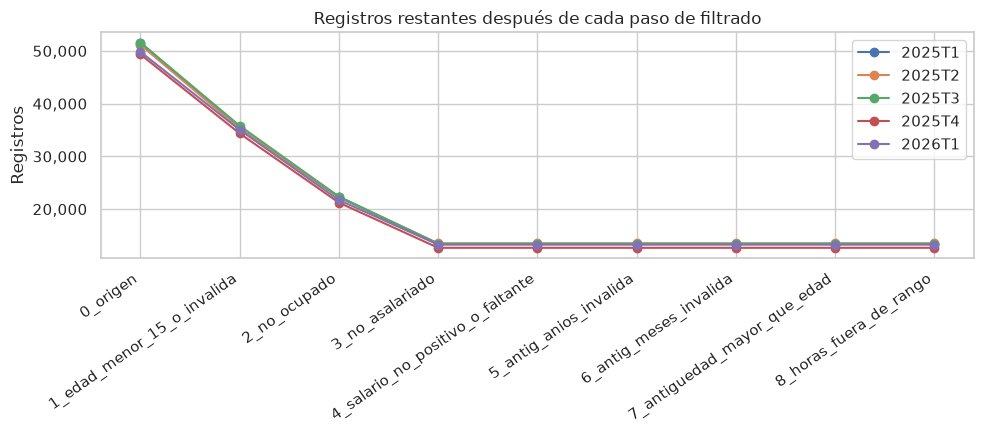

In [12]:
restantes = cascada.loc["0_registros_originales"] - cascada.loc[[f"excluidos_{p}" for p in NOMBRES_PASOS]].cumsum()
fig, ax = plt.subplots(figsize=(10, 4.5))
for p in PERIODOS_2025 + ["2026T1"]:
    ax.plot(["0_origen"] + NOMBRES_PASOS, [cascada.loc["0_registros_originales", p]] + list(restantes[p]), marker="o", label=p)
ax.set_title("Registros restantes después de cada paso de filtrado")
ax.set_ylabel("Registros")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.tick_params(axis="x", rotation=35)
plt.setp(ax.get_xticklabels(), ha="right")
ax.legend()
plt.tight_layout(); plt.show()

**Interpretación.** De 203,676 registros de 2025 se conservan **53,025 (26.0 %)**; en 2026T1, 13,258 de 49,843 (26.6 %). La proporción retenida es muy estable entre archivos (25.7 %–26.6 %).

- Los pasos 1 a 3 definen la *población* y explican **todas** las exclusiones: 62,886 menores de 15 años, 52,568 personas de 15+ no ocupadas y 35,197 ocupados no asalariados (cuenta propia, patronos, no remunerados).
- Los pasos 4 a 8 (calidad) no excluyen ningún registro: todos los asalariados ocupados de 15+ tienen salario positivo, meses de antigüedad entre 0 y 11, antigüedad ≤ edad y horas entre 1 y 168. Los datos publicados ya vienen validados en estas variables. Los filtros se mantienen en el código porque son la regla común que también se aplicará a 2026.
- No se imputó ningún valor.

### 1.6 Unicidad de `periodo_archivo + NUM_HOGAR + NUM_PERSONA`

La verificación se hace sobre los datos **crudos** (todas las filas) y sobre la base **filtrada**. Si existe alguna clave repetida se clasifica como:

- **Repetición exacta**: todas las columnas originales seleccionadas coinciden.
- **Registro en conflicto**: misma clave pero valores distintos en alguna columna.

In [13]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]


def auditar_clave(df, nombre):
    total = df.count()
    distintas = df.select(CLAVE).distinct().count()
    nulas = df.filter(F.col("NUM_HOGAR").isNull() | F.col("NUM_PERSONA").isNull()).count()
    print(f"{nombre}: {total:,} filas | {distintas:,} claves distintas | {total - distintas:,} filas sobrantes | {nulas:,} con clave nula")


auditar_clave(crudo_todo, "Crudo (5 archivos)")
auditar_clave(marcado_todo.filter(F.col("motivo_exclusion").isNull()), "Filtrado (5 archivos)")

cols_contenido = [c for c in COLS_ORIGINALES if c not in ("NUM_HOGAR", "NUM_PERSONA")]
dup = (crudo_todo
       .withColumn("firma", F.sha2(F.concat_ws("|", *[F.coalesce(F.col(c), F.lit("∅")) for c in cols_contenido]), 256))
       .groupBy(CLAVE)
       .agg(F.count("*").alias("n_filas"), F.countDistinct("firma").alias("n_versiones"))
       .filter("n_filas > 1")
       .withColumn("tipo", F.when(F.col("n_versiones") == 1, "repeticion_exacta").otherwise("conflicto")))

resumen_dup = dup.groupBy("periodo_archivo", "tipo").agg(F.count("*").alias("claves"), F.sum("n_filas").alias("filas")).toPandas()
resumen_dup if len(resumen_dup) else print("No hay claves duplicadas dentro de ningún período.")

Crudo (5 archivos): 253,519 filas | 253,519 claves distintas | 0 filas sobrantes | 0 con clave nula


Filtrado (5 archivos): 66,283 filas | 66,283 claves distintas | 0 filas sobrantes | 0 con clave nula


No hay claves duplicadas dentro de ningún período.


In [14]:
# Detalle de hasta 10 claves duplicadas (si las hay) para inspeccionar en qué columnas difieren
if len(resumen_dup):
    ejemplos = dup.orderBy(F.desc("n_versiones")).limit(10)
    crudo_todo.join(ejemplos.select(CLAVE + ["tipo"]), CLAVE).orderBy(CLAVE).show(40, truncate=False)

**Resultado.** La combinación `periodo_archivo + NUM_HOGAR + NUM_PERSONA` es **única** en los 253,519 registros crudos y en los 66,283 filtrados: no hay repeticiones exactas ni registros en conflicto, así que no fue necesario eliminar nada (y no se usó `dropDuplicates()`). El código de clasificación se deja para que el control sea reproducible: si en el futuro apareciera una clave repetida, se distinguiría entre *repetición exacta* (fila copiada en la fuente) y *conflicto* (la clave no identifica a una sola persona) y se marcaría en la columna `clave_duplicada`. Una misma persona en **períodos distintos** no es un duplicado.

### 1.7 Base preparada y guardado en Parquet

In [15]:
claves_dup = dup.select(CLAVE).withColumn("clave_duplicada", F.lit(True))

COLS_ANALITICAS = [
    "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario",
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE",
    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad", "horas_semanales",
    "nivel_educativo_cod", "nivel_educativo", "categoria_ocupacional_cod", "categoria_ocupacional",
    "dominio_cod", "dominio", "ocupado",
]


def preparar(marcado):
    return (marcado.filter(F.col("motivo_exclusion").isNull())
            .join(F.broadcast(claves_dup), CLAVE, "left")
            .withColumn("clave_duplicada", F.coalesce("clave_duplicada", F.lit(False)))
            .select(COLS_ANALITICAS + ["clave_duplicada"]))


preparado_2025 = preparar(marcado_2025)
preparado_2026 = preparar(marcado_2026)
preparado_2025.write.mode("overwrite").partitionBy("periodo_archivo").parquet(str(DATA_PROC / "eneic_2025_preparado.parquet"))
preparado_2026.write.mode("overwrite").parquet(str(DATA_PROC / "eneic_2026T1_preparado.parquet"))

df25 = spark.read.parquet(str(DATA_PROC / "eneic_2025_preparado.parquet")).cache()
df26 = spark.read.parquet(str(DATA_PROC / "eneic_2026T1_preparado.parquet")).cache()
print(f"2025 preparado: {df25.count():,} registros | 2026T1 preparado: {df26.count():,} registros")
df25.groupBy("periodo_archivo").count().orderBy("periodo_archivo").show()

2025 preparado: 53,025 registros | 2026T1 preparado: 13,258 registros
+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|13419|
|         2025T2|13492|
|         2025T3|13450|
|         2025T4|12664|
+---------------+-----+



### 1.8 Preguntas

**¿Por qué IV de 2025 no puede apilarse por posición de columnas con los otros archivos?**
Porque tiene **302 columnas** frente a las 270 de los demás: incorpora variables nuevas que desplazan el orden. Un `union()` posicional pegaría la columna *i* de un archivo con la columna *i* de otro aunque signifiquen cosas distintas (por ejemplo, un código de educación quedaría bajo el nombre de salario) sin generar ningún error, y los tipos podrían coincidir por casualidad. `unionByName` empareja las columnas por su **nombre**, lo que garantiza que cada variable se combine con su equivalente, independientemente de su posición. Además, antes de unir se normalizan los encabezados y se seleccionan solo las columnas requeridas.

**¿Qué diferencia existe entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
Un ausente *porque no corresponde* es **estructural**: el cuestionario tiene saltos (filtros) y, por diseño, a un menor de edad, a un inactivo o a un trabajador por cuenta propia no se le pregunta el sueldo de asalariado. No es información perdida; la variable simplemente no aplica y esas personas quedan fuera de la población analítica. Una *respuesta no registrada* es **no respuesta**: la pregunta sí aplicaba (asalariado de 15+ años) pero el dato no se capturó (se negó, no sabía, error de captura). Solo esta última es un problema de calidad que puede sesgar resultados. La sección 1.4 lo muestra con los datos: el 74 % de nulos del salario corresponde **totalmente** a personas a quienes no se les pregunta (100 % de nulos fuera de la población y 0 % dentro). Tratar esos nulos como no respuesta, o imputarlos, sería un error grave.

**¿Por qué una persona observada en dos períodos no debe eliminarse como duplicado del conjunto longitudinal?**
La ENEIC es un panel rotativo: un hogar permanece varios trimestres en la muestra. Cada fila representa a una **persona en un período**, con su edad, salario, horas y antigüedad de *ese* trimestre. Dos observaciones de la misma persona en trimestres distintos son mediciones diferentes y legítimas, no copias. Eliminarlas reduciría artificialmente la muestra de ciertos trimestres, rompería la comparabilidad entre cortes y sesgaría los resultados hacia los hogares que rotan antes. Por eso la unicidad se verifica **dentro** de cada `periodo_archivo`. (Para la validación de los modelos sí conviene recordar que las observaciones repetidas no son independientes.)

**¿Por qué el número de registros de la base filtrada no representa a todos los trabajadores del país?**
1. Es una **muestra**, no un censo: cada registro representa a muchas personas según su `FACTOR` de expansión, y aquí se trabaja sin ponderar.
2. La población está **restringida** a asalariados de 15+ años con salario positivo registrado; excluye trabajadores por cuenta propia, patronos, familiares no remunerados y a quienes no reportaron salario (la no respuesta puede no ser aleatoria, p. ej. en salarios altos).
3. Al unir cuatro trimestres, **una persona puede aparecer varias veces**, así que el número de filas no equivale a personas distintas.
4. Se excluyeron registros por reglas de calidad.

El `FACTOR` se conservó porque, en un análisis poblacional, se usaría como peso para expandir la muestra (totales, medias y percentiles ponderados) y, junto con el diseño muestral (estratos y UPM), para calcular errores estándar correctos. En este laboratorio los resultados describen **los registros analizados**, no estimaciones oficiales.

---
# 2. Estadística descriptiva y preguntas de exploración

Todos los estadísticos se calculan en Spark sobre **toda** la población analítica de 2025. Los percentiles se obtienen con la función exacta `percentile` de Spark SQL.

In [16]:
VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]


def resumen_num(df, cols):
    filas = []
    for c in cols:
        r = df.agg(
            F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_est"),
            F.min(c).alias("min"), F.max(c).alias("max"),
            F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
            F.skewness(c).alias("asimetria"),
        ).first()
        filas.append({"variable": c, "n": r["n"], "media": r["media"], "mediana": r["p"][1],
                      "desv_est": r["desv_est"], "min": r["min"], "p25": r["p"][0], "p75": r["p"][2],
                      "p95": r["p"][3], "max": r["max"], "asimetria": r["asimetria"]})
    return pd.DataFrame(filas).set_index("variable")


desc25 = resumen_num(df25, VARS_NUM)
desc25

,n,media,mediana,desv_est,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,"3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00",6.00
edad,53025,35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00,0.74
antiguedad,53025,5.56,2.00,7.83,0.00,0.50,7.00,22.00,70.00,2.40
horas_semanales,53025,46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00,0.59


In [17]:
s = desc25.loc["salario_mensual"]
print(f"Salario: media Q{s.media:,.2f} vs mediana Q{s.mediana:,.2f} -> diferencia Q{s.media - s.mediana:,.2f} "
      f"({100 * (s.media / s.mediana - 1):.1f}% sobre la mediana); asimetría = {s.asimetria:.2f}")
print(f"El 5% mejor pagado gana más de Q{s.p95:,.2f}; el máximo es {s['max'] / s.mediana:,.1f} veces la mediana.")

Salario: media Q3,421.68 vs mediana Q3,000.00 -> diferencia Q421.68 (14.1% sobre la mediana); asimetría = 6.00
El 5% mejor pagado gana más de Q8,000.00; el máximo es 33.0 veces la mediana.


### 2.1 Distribución de registros entre categorías ocupacionales, niveles educativos y dominios

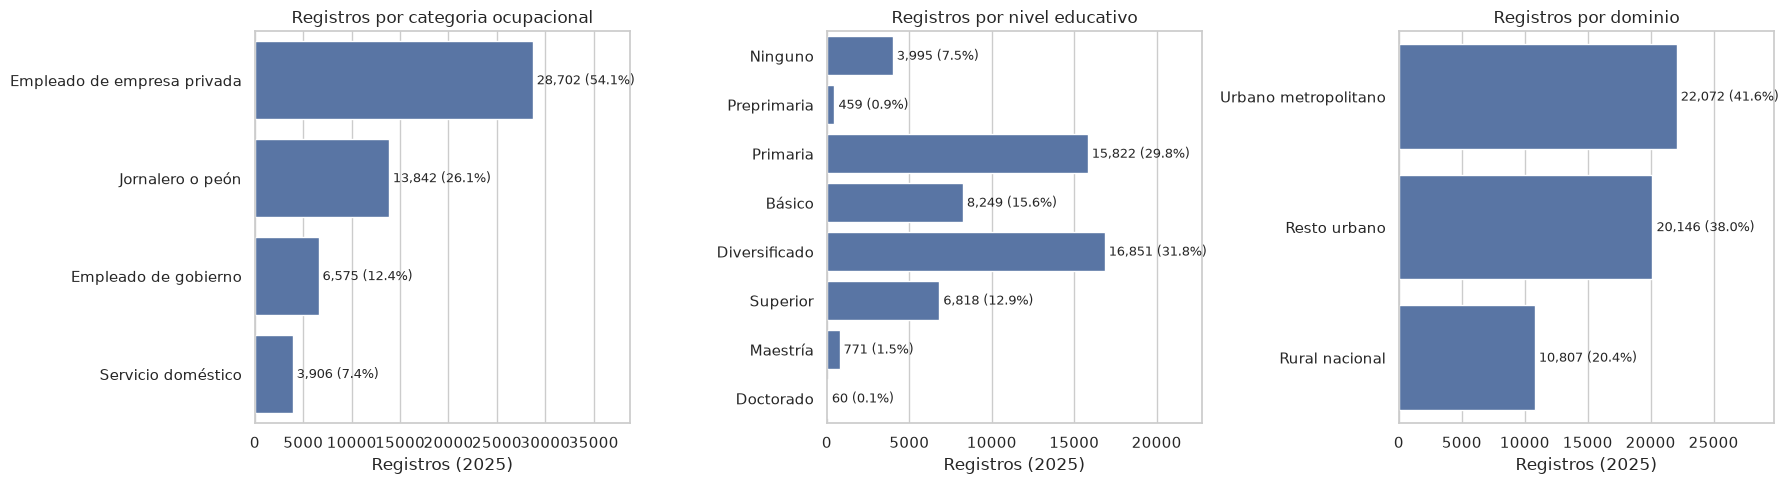

In [18]:
def frecuencias(df, col, orden=None):
    pdf = df.groupBy(col).count().toPandas()
    pdf["pct"] = 100 * pdf["count"] / pdf["count"].sum()
    if orden:
        pdf[col] = pd.Categorical(pdf[col], categories=[o for o in orden if o in set(pdf[col])], ordered=True)
        return pdf.sort_values(col)
    return pdf.sort_values("count", ascending=False)


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (col, orden) in zip(axes, [("categoria_ocupacional", None), ("nivel_educativo", ORDEN_EDU), ("dominio", None)]):
    f = frecuencias(df25, col, orden)
    sns.barplot(data=f, x="count", y=col, ax=ax, color="#4C72B0")
    for i, (n, p) in enumerate(zip(f["count"], f["pct"])):
        ax.text(n, i, f" {n:,} ({p:.1f}%)", va="center", fontsize=9)
    ax.set_title(f"Registros por {col.replace('_', ' ')}")
    ax.set_xlabel("Registros (2025)"); ax.set_ylabel("")
    ax.set_xlim(0, f["count"].max() * 1.35)
plt.tight_layout(); plt.show()

**Interpretación.**
- **Categoría ocupacional:** los empleados de **empresa privada** son más de la mitad de los registros (28,702; 54.1 %), seguidos por **jornaleros o peones** (13,842; 26.1 %), **empleados de gobierno** (6,575; 12.4 %) y **servicio doméstico** (3,906; 7.4 %).
- **Nivel educativo:** predominan **diversificado** (31.8 %) y **primaria** (29.8 %), seguidos por básico (15.6 %), superior (12.9 %) y ninguno (7.5 %). Maestría (771; 1.5 %), preprimaria (459) y sobre todo **doctorado (60 registros)** son grupos muy pequeños: sus estadísticas serán inestables y, en los modelos, sus categorías *one‑hot* tendrán poco soporte. No quedaron registros `DESCONOCIDO` en la población analítica.
- **Dominio:** urbano metropolitano 41.6 %, resto urbano 38.0 % y rural nacional 20.4 %. Estas proporciones reflejan el **diseño muestral** (sobremuestreo por dominio) y la concentración del empleo asalariado en zonas urbanas; como no están ponderadas, no son la distribución nacional.

### 2.2 Forma de la distribución del salario

Muestra para gráficos: 10,000 de 53,025 registros


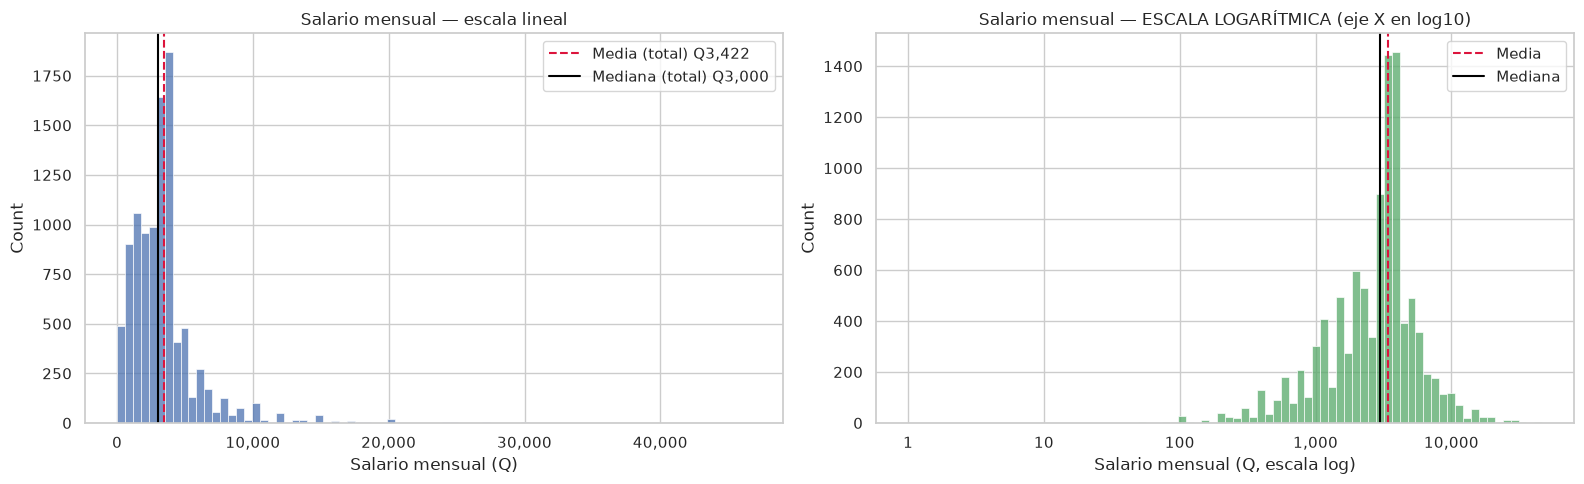

In [19]:
n25 = df25.count()
muestra = (df25.sample(fraction=min(1.0, N_MUESTRA_GRAF / n25), seed=SEED)
           .limit(N_MUESTRA_GRAF).select(VARS_NUM + ["nivel_educativo", "categoria_ocupacional", "dominio"]).toPandas())
print(f"Muestra para gráficos: {len(muestra):,} de {n25:,} registros")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
ax = axes[0]
sns.histplot(muestra["salario_mensual"], bins=80, ax=ax, color="#4C72B0")
ax.axvline(s.media, color="crimson", ls="--", label=f"Media (total) Q{s.media:,.0f}")
ax.axvline(s.mediana, color="black", ls="-", label=f"Mediana (total) Q{s.mediana:,.0f}")
ax.set_title("Salario mensual — escala lineal")
ax.set_xlabel("Salario mensual (Q)"); ax.legend()
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))

ax = axes[1]
sns.histplot(muestra["salario_mensual"], bins=80, log_scale=True, ax=ax, color="#55A868")
ax.axvline(s.media, color="crimson", ls="--", label="Media")
ax.axvline(s.mediana, color="black", ls="-", label="Mediana")
ax.set_title("Salario mensual — ESCALA LOGARÍTMICA (eje X en log10)")
ax.set_xlabel("Salario mensual (Q, escala log)"); ax.legend()
ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**¿El salario presenta una distribución simétrica o asimétrica?** Es **fuertemente asimétrica a la derecha**: el coeficiente de asimetría calculado sobre los 53,025 registros es **6.0**. La mitad central de los salarios está entre **Q1,800 (P25) y Q4,000 (P75)**, el P95 es Q8,000 y la cola se extiende hasta **Q99,000**, 33 veces la mediana. En escala logarítmica la distribución se vuelve mucho más simétrica, con una forma cercana a la log‑normal. Se ven picos en valores redondos (Q3,000, Q4,000…), típicos de salarios declarados en una encuesta. En el extremo inferior hay pocos salarios muy bajos (P1 = Q225, mínimo Q1; 22 registros bajo Q100) que probablemente corresponden a trabajos de pocas horas o a errores de declaración. Se conservan, como pide la guía, y su influencia se discutirá en el modelado. La escala log solo se usa para visualizar: el objetivo sigue siendo `salario_mensual` en quetzales.

**¿Qué diferencia existe entre su media y su mediana?** La **media (Q3,421.68) supera a la mediana (Q3,000.00) en Q421.68, un 14.1 %**. La cola derecha "jala" la media hacia arriba, mientras que la mediana representa mejor al asalariado típico; por eso las comparaciones entre grupos usan la mediana. La desviación estándar (Q2,902) es casi del tamaño de la media, otra señal de alta dispersión. Los salarios extremos **no se eliminan**, pero pesarán mucho en métricas cuadráticas como el RMSE: unos pocos salarios de Q30,000+ pueden dominar el error de los modelos.

### 2.3 Salario mediano por nivel educativo y categoría ocupacional

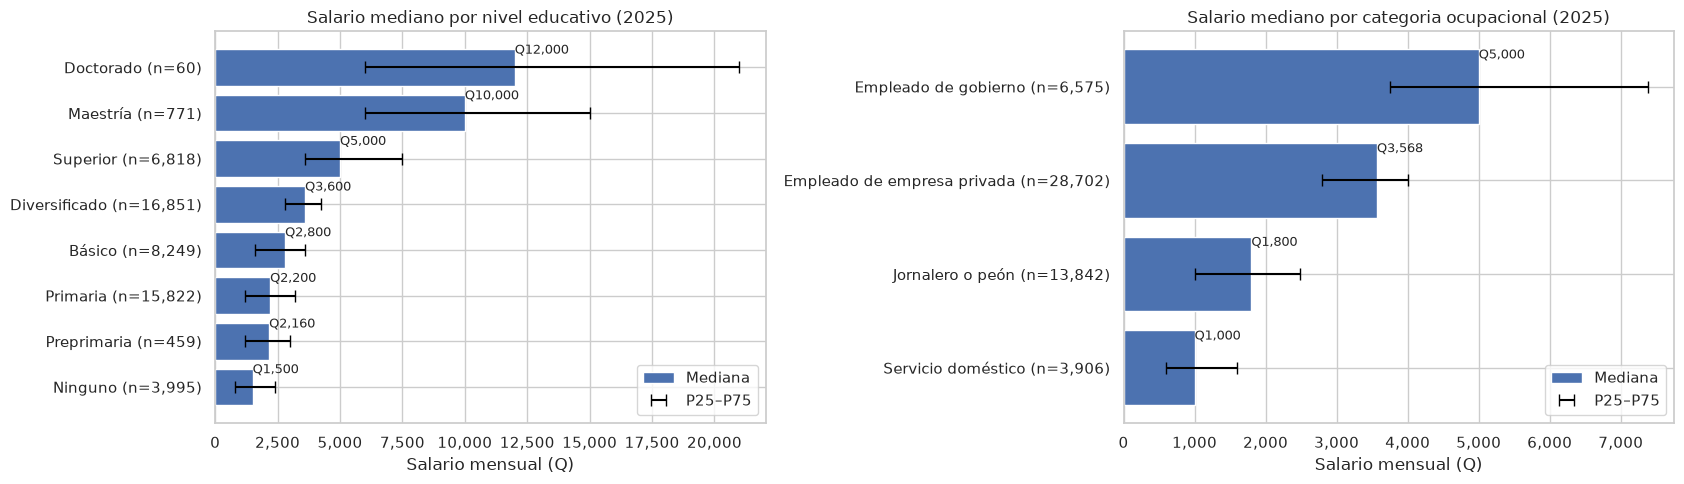

,n,mediana,p25,p75,media
nivel_educativo,,,,,
Ninguno,3995,"1,500.00",800.00,"2,400.00","1,767.09"
Preprimaria,459,"2,160.00","1,200.00","3,000.00","2,241.90"
Primaria,15822,"2,200.00","1,200.00","3,200.00","2,307.96"
Básico,8249,"2,800.00","1,600.00","3,600.00","2,730.20"
Diversificado,16851,"3,600.00","2,800.00","4,250.00","3,796.41"
Superior,6818,"5,000.00","3,600.00","7,500.00","5,965.30"
Maestría,771,"10,000.00","6,000.00","15,000.00","11,409.27"
Doctorado,60,"12,000.00","6,000.00","21,000.00","14,452.27"


,n,mediana,p25,p75,media
categoria_ocupacional,,,,,
Servicio doméstico,3906,"1,000.00",600.00,"1,600.00","1,265.74"
Jornalero o peón,13842,"1,800.00","1,000.00","2,489.75","1,878.61"
Empleado de empresa privada,28702,"3,567.50","2,800.00","4,000.00","3,875.14"
Empleado de gobierno,6575,"5,000.00","3,750.00","7,380.00","5,971.53"


In [20]:
def mediana_por(df, col, valor="salario_mensual"):
    return (df.groupBy(col).agg(F.count("*").alias("n"),
                                F.expr(f"percentile({valor}, 0.5)").alias("mediana"),
                                F.expr(f"percentile({valor}, 0.25)").alias("p25"),
                                F.expr(f"percentile({valor}, 0.75)").alias("p75"),
                                F.mean(valor).alias("media")).toPandas())


med_edu = mediana_por(df25, "nivel_educativo")
med_edu["nivel_educativo"] = pd.Categorical(med_edu["nivel_educativo"], [o for o in ORDEN_EDU if o in set(med_edu["nivel_educativo"])], ordered=True)
med_edu = med_edu.sort_values("nivel_educativo")
med_cat = mediana_por(df25, "categoria_ocupacional").sort_values("mediana")

fig, axes = plt.subplots(1, 2, figsize=(17, 5))
for ax, tabla, col in [(axes[0], med_edu, "nivel_educativo"), (axes[1], med_cat, "categoria_ocupacional")]:
    y = np.arange(len(tabla))
    ax.barh(y, tabla["mediana"], color="#4C72B0", label="Mediana")
    ax.errorbar(tabla["mediana"], y, xerr=[tabla["mediana"] - tabla["p25"], tabla["p75"] - tabla["mediana"]],
                fmt="none", ecolor="black", capsize=4, label="P25–P75")
    ax.set_yticks(y, [f"{c} (n={n:,})" for c, n in zip(tabla[col], tabla["n"])])
    for yi, m in zip(y, tabla["mediana"]):
        ax.text(m, yi + 0.3, f"Q{m:,.0f}", fontsize=9)
    ax.set_title(f"Salario mediano por {col.replace('_', ' ')} (2025)")
    ax.set_xlabel("Salario mensual (Q)")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.legend(loc="lower right")
plt.tight_layout(); plt.show()
display(med_edu.set_index("nivel_educativo"), med_cat.set_index("categoria_ocupacional"))

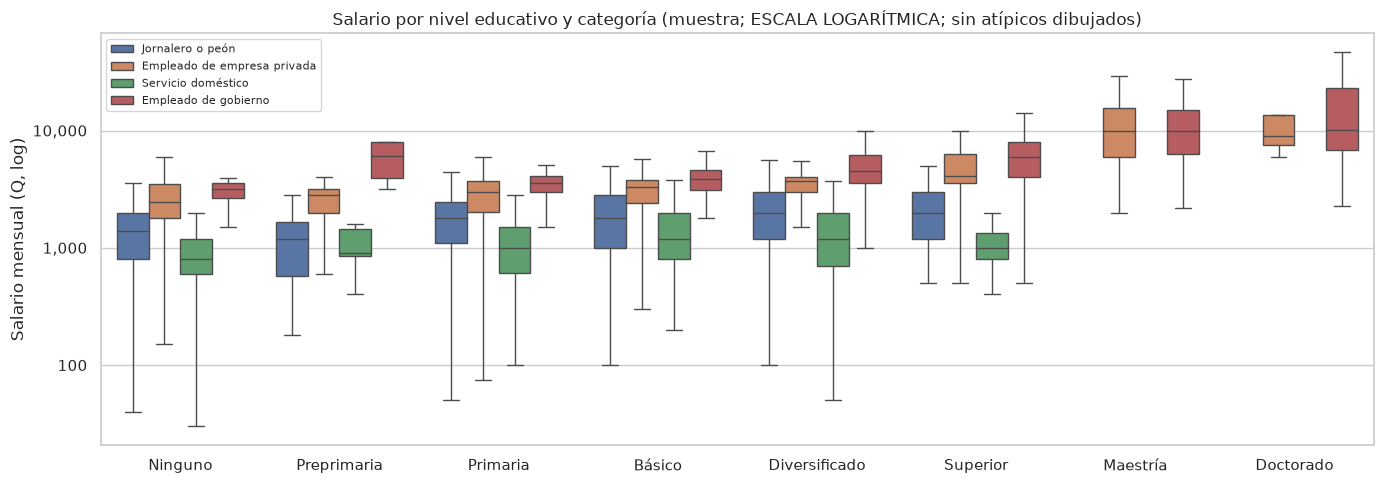

In [21]:
fig, ax = plt.subplots(figsize=(14, 5))
orden_m = [o for o in ORDEN_EDU if o in set(muestra["nivel_educativo"])]
sns.boxplot(data=muestra, x="nivel_educativo", y="salario_mensual", hue="categoria_ocupacional",
            order=orden_m, showfliers=False, ax=ax)
ax.set_yscale("log")
ax.set_title("Salario por nivel educativo y categoría (muestra; ESCALA LOGARÍTMICA; sin atípicos dibujados)")
ax.set_ylabel("Salario mensual (Q, log)"); ax.set_xlabel("")
ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
ax.legend(title="", fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

**Interpretación.**
- **Nivel educativo:** el salario mediano **crece de forma monótona con la educación**: Ninguno Q1,500 → Preprimaria Q2,160 → Primaria Q2,200 → Básico Q2,800 → Diversificado Q3,600 → Superior Q5,000 → Maestría Q10,000 → Doctorado Q12,000. El gradiente es suave hasta básico y se **acelera desde diversificado**: la mediana de maestría duplica la de superior. También se amplía el rango intercuartílico (Maestría: Q6,000–Q15,000), así que los niveles altos no solo ganan más, sino también de forma más heterogénea. La mediana de doctorado se basa en solo 60 registros.
- **Categoría ocupacional:** servicio doméstico Q1,000 < jornalero o peón Q1,800 < empresa privada Q3,567.50 < **gobierno Q5,000**. La mediana del gobierno es **5 veces** la del servicio doméstico. La distribución de empresa privada es muy concentrada (P25–P75: Q2,800–Q4,000), cerca del salario mínimo. En los jornaleros y el servicio doméstico, el P75 queda por debajo de la mediana general, lo que es coherente con trabajos por jornal o de tiempo parcial.
- El boxplot conjunto muestra que **dentro de un mismo nivel educativo persisten brechas entre categorías**, y que parte de la ventaja del gobierno se explica porque concentra a más personas con educación superior. Son asociaciones descriptivas, no efectos causales.

### 2.4 Tamaño de la muestra analítica y salario mediano por trimestre

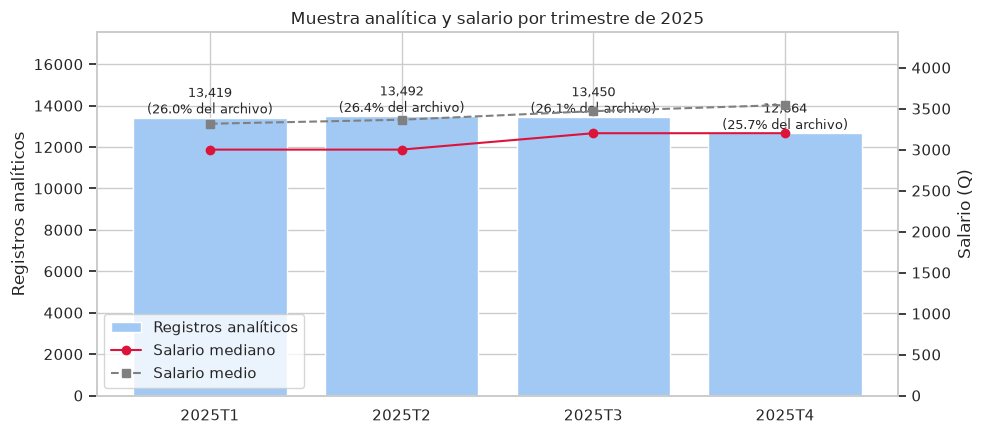

,periodo_archivo,n,mediana,media,originales,pct_retenido
0,2025T1,13419,"3,000.00","3,315.63","51,588.00",26.01
1,2025T2,13492,"3,000.00","3,364.57","51,167.00",26.37
2,2025T3,13450,"3,200.00","3,469.07","51,583.00",26.07
3,2025T4,12664,"3,200.00","3,544.57","49,338.00",25.67


In [22]:
por_trim = (df25.groupBy("periodo_archivo")
            .agg(F.count("*").alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                 F.mean("salario_mensual").alias("media"))
            .orderBy("periodo_archivo").toPandas())
por_trim = por_trim.merge(cascada.loc["0_registros_originales", PERIODOS_2025].rename("originales"),
                          left_on="periodo_archivo", right_index=True)
por_trim["pct_retenido"] = 100 * por_trim["n"] / por_trim["originales"]

fig, ax1 = plt.subplots(figsize=(10, 4.5))
ax1.bar(por_trim["periodo_archivo"], por_trim["n"], color="#A1C9F4", label="Registros analíticos")
for x, n, p in zip(por_trim["periodo_archivo"], por_trim["n"], por_trim["pct_retenido"]):
    ax1.text(x, n, f"{n:,}\n({p:.1f}% del archivo)", ha="center", va="bottom", fontsize=9)
ax1.set_ylabel("Registros analíticos"); ax1.set_ylim(0, por_trim["n"].max() * 1.3)
ax2 = ax1.twinx()
ax2.plot(por_trim["periodo_archivo"], por_trim["mediana"], color="crimson", marker="o", label="Salario mediano")
ax2.plot(por_trim["periodo_archivo"], por_trim["media"], color="gray", marker="s", ls="--", label="Salario medio")
ax2.set_ylabel("Salario (Q)"); ax2.grid(False)
ax2.set_ylim(0, por_trim["media"].max() * 1.25)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower left")
ax1.set_title("Muestra analítica y salario por trimestre de 2025")
plt.tight_layout(); plt.show()
por_trim

**Interpretación.**
- **Tamaño:** la muestra analítica es muy estable en T1–T3 (13,419; 13,492; 13,450) y **baja en T4 (12,664, −6 %)**, en parte porque el archivo de IV‑2025 tiene menos registros (49,338). La proporción retenida se mantiene cerca de 26 % en todos, así que ningún trimestre domina el entrenamiento.
- **Salario:** la mediana es **Q3,000 en T1 y T2 y sube a Q3,200 en T3 y T4** (+6.7 %). La media crece de forma continua (Q3,316 → Q3,365 → Q3,469 → Q3,545; +6.9 % en el año). Es una tendencia creciente moderada; la mediana avanza en escalones porque los salarios se declaran en valores redondos.
- Estas variaciones pueden reflejar ajustes salariales, pero también la **rotación de la muestra** y la estacionalidad del empleo (p. ej., cosechas que cambian el peso de los jornaleros). Para la prueba en 2026T1 significa que un modelo entrenado con 2025 podría quedar ligeramente desfasado si la tendencia continúa.

---
# 3. Relaciones entre variables numéricas

Correlación de **Pearson** con `VectorAssembler` + `Correlation.corr()` sobre **todos** los registros elegibles de 2025.

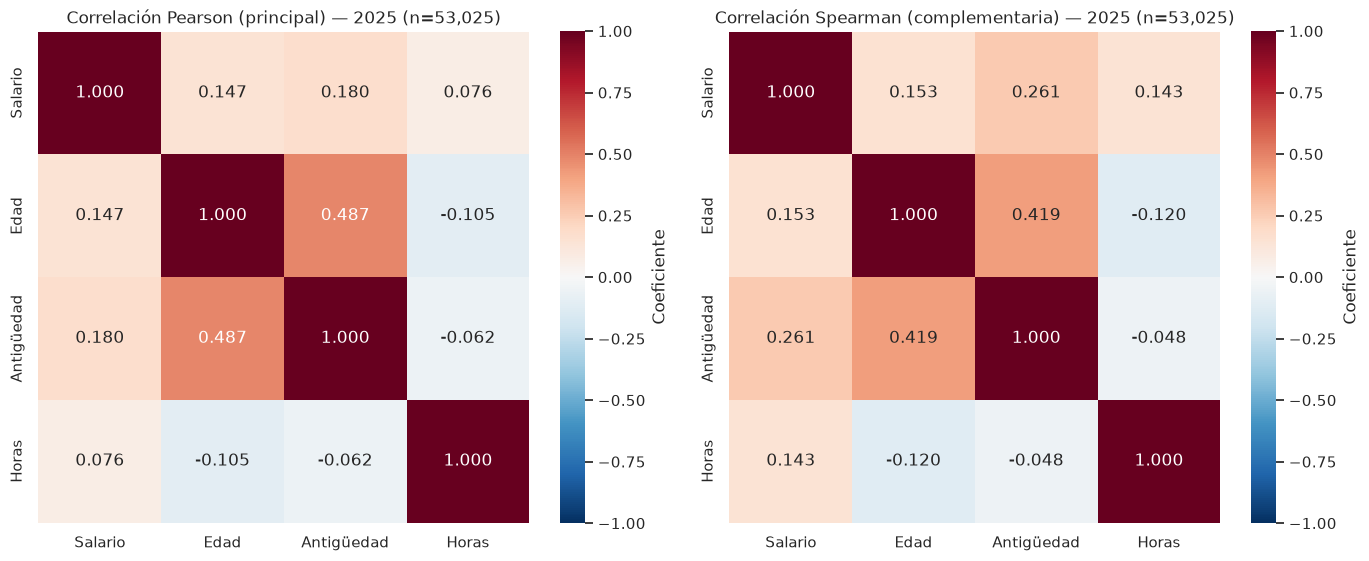

,Salario,Edad,Antigüedad,Horas
Salario,1.00,0.15,0.18,0.08
Edad,0.15,1.00,0.49,-0.11
Antigüedad,0.18,0.49,1.00,-0.06
Horas,0.08,-0.11,-0.06,1.00


In [23]:
va_corr = VectorAssembler(inputCols=VARS_NUM, outputCol="vec_corr")
vec = va_corr.transform(df25).select("vec_corr")
pearson = Correlation.corr(vec, "vec_corr", "pearson").head()[0].toArray()
spearman = Correlation.corr(vec, "vec_corr", "spearman").head()[0].toArray()   # complemento: robusta a asimetría

etiquetas = ["Salario", "Edad", "Antigüedad", "Horas"]
corr_p = pd.DataFrame(pearson, index=etiquetas, columns=etiquetas)
corr_s = pd.DataFrame(spearman, index=etiquetas, columns=etiquetas)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, m, t in [(axes[0], corr_p, "Pearson (principal)"), (axes[1], corr_s, "Spearman (complementaria)")]:
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                cbar_kws={"label": "Coeficiente"})
    ax.set_title(f"Correlación {t} — 2025 (n={n25:,})")
plt.tight_layout(); plt.show()
corr_p

In [24]:
cs = corr_p["Salario"].drop("Salario").sort_values(key=np.abs, ascending=False)
print("Correlación de Pearson con el salario (ordenada por magnitud):")
print(cs.round(3).to_string())
print(f"\nEdad vs antigüedad: Pearson = {corr_p.loc['Edad', 'Antigüedad']:.3f}, Spearman = {corr_s.loc['Edad', 'Antigüedad']:.3f}")

Correlación de Pearson con el salario (ordenada por magnitud):
Antigüedad   0.18
Edad         0.15
Horas        0.08

Edad vs antigüedad: Pearson = 0.487, Spearman = 0.419


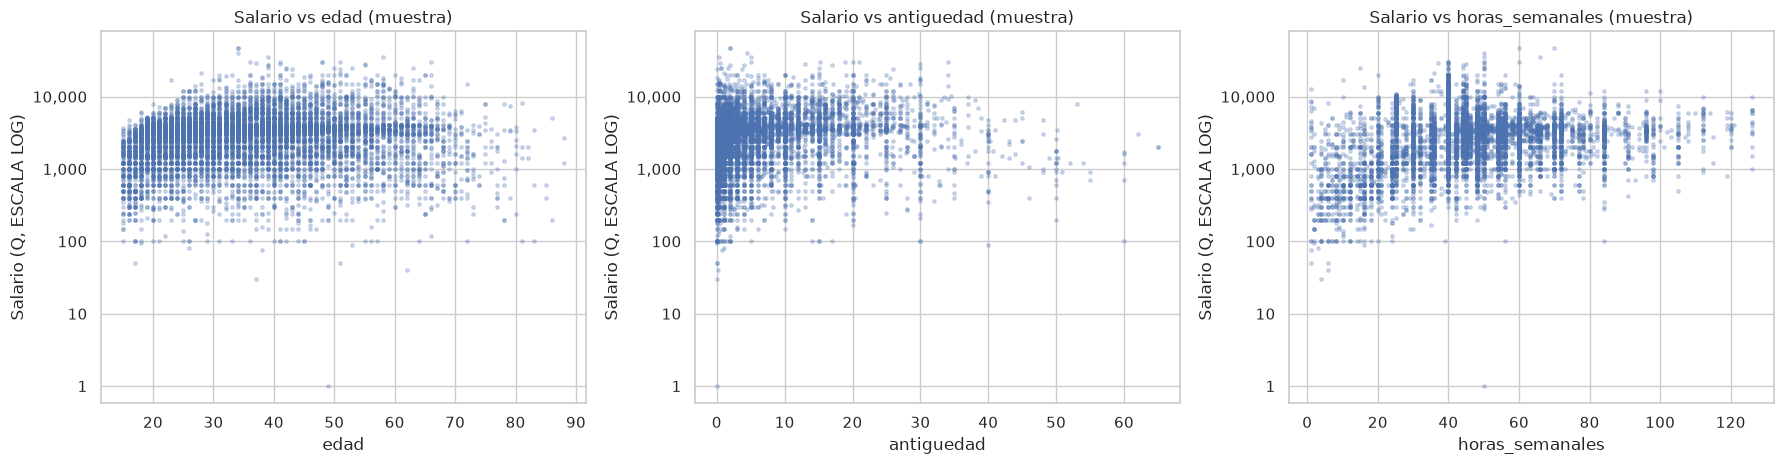

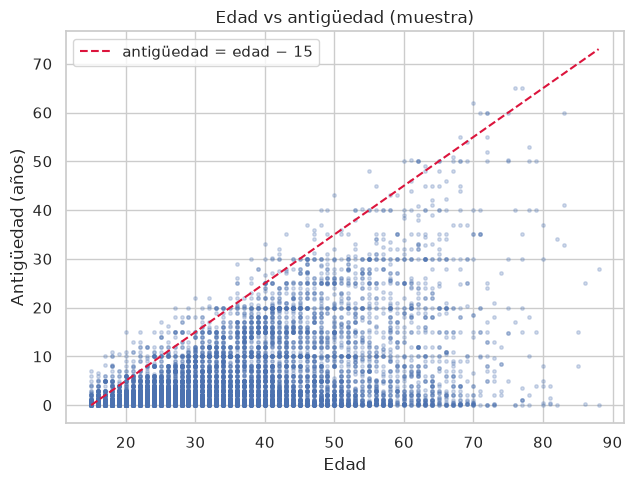

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))
for ax, x in zip(axes, ["edad", "antiguedad", "horas_semanales"]):
    ax.scatter(muestra[x], muestra["salario_mensual"], s=6, alpha=0.25)
    ax.set_yscale("log")
    ax.set_xlabel(x); ax.set_ylabel("Salario (Q, ESCALA LOG)")
    ax.set_title(f"Salario vs {x} (muestra)")
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(6.5, 5))
ax.scatter(muestra["edad"], muestra["antiguedad"], s=6, alpha=0.25)
ax.plot([15, muestra["edad"].max()], [0, muestra["edad"].max() - 15], color="crimson", ls="--", label="antigüedad = edad − 15")
ax.set_xlabel("Edad"); ax.set_ylabel("Antigüedad (años)"); ax.legend()
ax.set_title("Edad vs antigüedad (muestra)")
plt.tight_layout(); plt.show()

**¿Qué variables presentan mayor asociación lineal con el salario?** Todas las correlaciones de Pearson con el salario son **positivas pero débiles**:
- **Antigüedad: r = 0.18**, la mayor. Más tiempo en el mismo empleo se asocia a salarios algo mayores.
- **Edad: r = 0.15.**
- **Horas habituales: r = 0.08**, prácticamente nula. Las jornadas largas se concentran en ocupaciones de bajo salario, y parte de las jornadas cortas son de profesionales bien pagados, así que ambos efectos se compensan.

Aun la variable más asociada explica apenas ~3 % de la varianza lineal del salario (r² ≈ 0.03). El salario depende mucho más de factores **categóricos** (la mediana va de Q1,500 a Q12,000 según la educación y de Q1,000 a Q5,000 según la categoría) y de relaciones no lineales. Además, Pearson es sensible a los salarios extremos; la matriz de Spearman, basada en rangos, sirve de control de robustez. Para la regresión lineal, esto anticipa un R² modesto si solo se usaran las variables numéricas.

**¿Existe relación entre edad y antigüedad?** Sí: es la asociación **más fuerte de la matriz (Pearson = 0.49; Spearman = 0.42)**, positiva y moderada. Tiene sentido estructural: la antigüedad está acotada por la edad, y el diagrama forma un "triángulo" bajo la línea antigüedad = edad − 15. Los jóvenes solo pueden tener poca antigüedad, mientras que los mayores pueden tener mucha o poca, según si cambiaron de empleo. No es una relación redundante (r < 0.5), pero sí una colinealidad moderada que debe considerarse al interpretar los coeficientes de la regresión lineal. Edad y horas tienen una relación ligeramente negativa (r = −0.11): los trabajadores de mayor edad tienden a jornadas un poco más cortas.

---
# 4. Segmentación de perfiles mediante KMeans

### 4.1 Selección de variables — ¿incluir el salario?

Se comparan dos especificaciones:

| Opción | Variables | Justificación |
|---|---|---|
| **A (principal)** | edad, antigüedad, horas semanales | Perfiles según características personales/laborales observadas, sin usar el objetivo |
| **B (comparación)** | edad, antigüedad, horas semanales, log10(salario) | Evalúa qué ocurre si se incluye el salario |

Argumentos para **no** incluir el salario en la segmentación principal:
1. Es la **variable objetivo** del modelado supervisado; construir perfiles con ella y luego describir el salario por perfil sería circular.
2. Su **fuerte asimetría** haría que, sin transformar, unos pocos salarios extremos definieran clusters casi individuales; aun en log domina la distancia.
3. La pregunta de negocio es *qué perfiles de trabajadores existen*, y luego *cómo difiere el salario entre ellos*: el salario se usa para **describir** los clusters, no para formarlos.

Las variables se **estandarizan** (`StandardScaler`, media 0 y desviación 1) porque KMeans usa distancia euclidiana y, sin escalar, las variables con mayor rango (antigüedad en años vs horas) dominarían.

Las variables categóricas no se incluyen directamente en KMeans (las distancias euclidianas sobre variables *one‑hot* no son apropiadas); se usan después para caracterizar los grupos.

In [26]:
VARS_A = ["edad", "antiguedad", "horas_semanales"]
VARS_B = VARS_A + ["log_salario"]
K_VALORES = [2, 3, 4, 5]

base_km = df25.withColumn("log_salario", F.log10("salario_mensual")).cache()
evaluador = ClusteringEvaluator(featuresCol="features", predictionCol="cluster", metricName="silhouette",
                                distanceMeasure="squaredEuclidean")


def pipeline_kmeans(cols, k):
    return Pipeline(stages=[
        VectorAssembler(inputCols=cols, outputCol="x"),
        StandardScaler(inputCol="x", outputCol="features", withMean=True, withStd=True),
        KMeans(k=k, seed=SEED, featuresCol="features", predictionCol="cluster", maxIter=100, initSteps=5),
    ])


resultados, modelos = [], {}
for opcion, cols in [("A: sin salario", VARS_A), ("B: con log(salario)", VARS_B)]:
    for k in K_VALORES:
        modelo = pipeline_kmeans(cols, k).fit(base_km)
        pred = modelo.transform(base_km)
        tam = pred.groupBy("cluster").count().toPandas()["count"]
        resultados.append({
            "opcion": opcion, "k": k,
            "silueta": evaluador.evaluate(pred),
            "wssse": modelo.stages[-1].summary.trainingCost,
            "pct_cluster_mas_pequeno": 100 * tam.min() / tam.sum(),
        })
        modelos[(opcion, k)] = modelo

res_km = pd.DataFrame(resultados)
res_km

,opcion,k,silueta,wssse,pct_cluster_mas_pequeno
0,A: sin salario,2,0.55,"106,717.39",27.54
1,A: sin salario,3,0.44,"84,468.15",13.54
2,A: sin salario,4,0.47,"64,437.03",12.91
3,A: sin salario,5,0.44,"62,008.36",5.03
4,B: con log(salario),2,0.47,"159,174.10",28.27
5,B: con log(salario),3,0.48,"125,145.17",17.60
6,B: con log(salario),4,0.37,"107,227.29",11.43
7,B: con log(salario),5,0.39,"91,789.34",10.54


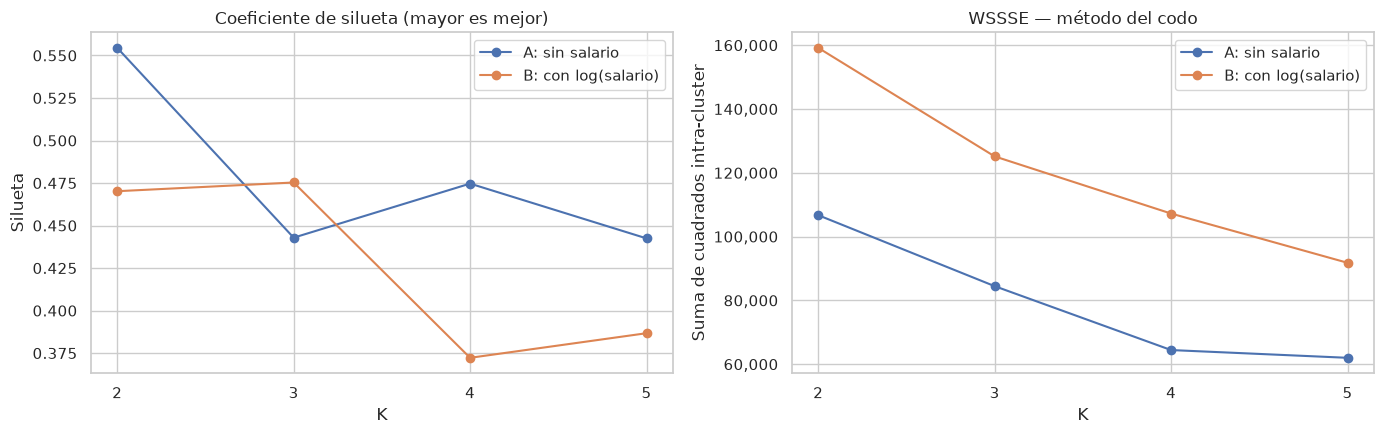

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for opcion, g in res_km.groupby("opcion"):
    axes[0].plot(g["k"], g["silueta"], marker="o", label=opcion)
    axes[1].plot(g["k"], g["wssse"], marker="o", label=opcion)
axes[0].set_title("Coeficiente de silueta (mayor es mejor)"); axes[0].set_xlabel("K"); axes[0].set_ylabel("Silueta")
axes[1].set_title("WSSSE — método del codo"); axes[1].set_xlabel("K"); axes[1].set_ylabel("Suma de cuadrados intra‑cluster")
for ax in axes:
    ax.set_xticks(K_VALORES); ax.legend()
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

### 4.2 Criterio del grupo para elegir K

Se elige K en la **opción A** combinando tres condiciones:
1. **Codo del WSSSE:** el menor K a partir del cual agregar un cluster más reduce la suma de cuadrados intra‑cluster en **menos de 10 %** (rendimientos decrecientes).
2. **Silueta aceptable (≥ 0.40)**, calculada sobre todos los registros.
3. Cluster más pequeño con **al menos 5 %** de los registros, para que cada perfil sea útil y estable.

No se usa solo la silueta máxima porque favorece sistemáticamente K = 2, que parte la población en "jóvenes" y "mayores" sin distinguir, por ejemplo, la jornada. Ese resultado es poco informativo para el objetivo del laboratorio.

In [28]:
res_a = res_km[res_km["opcion"] == "A: sin salario"].set_index("k").copy()
res_a["reduccion_wssse_al_siguiente_k_%"] = 100 * (1 - res_a["wssse"].shift(-1) / res_a["wssse"])
display(res_a[["silueta", "wssse", "reduccion_wssse_al_siguiente_k_%", "pct_cluster_mas_pequeno"]])

validos = res_a[(res_a["silueta"] >= 0.40) & (res_a["pct_cluster_mas_pequeno"] >= 5)]
codo = validos[validos["reduccion_wssse_al_siguiente_k_%"] < 10]
K_ELEGIDO = int(codo.index.min() if len(codo) else validos["silueta"].idxmax())
print(f"K elegido (opción A): {K_ELEGIDO}")
print(res_km[res_km["k"] == K_ELEGIDO].set_index("opcion")[["silueta", "pct_cluster_mas_pequeno"]])

modelo_km = modelos[("A: sin salario", K_ELEGIDO)]
seg = modelo_km.transform(base_km).drop("x", "features").cache()

,silueta,wssse,reduccion_wssse_al_siguiente_k_%,pct_cluster_mas_pequeno
k,,,,
2,0.55,"106,717.39",20.85,27.54
3,0.44,"84,468.15",23.71,13.54
4,0.47,"64,437.03",3.77,12.91
5,0.44,"62,008.36",NaN,5.03


K elegido (opción A): 4
                     silueta  pct_cluster_mas_pequeno
opcion                                               
A: sin salario          0.47                    12.91
B: con log(salario)     0.37                    11.43


**Elección de K.** La reducción del WSSSE es grande de K = 2 a 3 (−21 %) y de 3 a 4 (−24 %), pero **casi nula de 4 a 5 (−4 %)**: el codo está en **K = 4**. Además, K = 4 es un **máximo local de la silueta (0.47**, frente a 0.44 con K = 3 y K = 5) y su cluster más pequeño tiene 12.9 % de los registros. K = 5 apenas mejora el ajuste y genera un grupo de solo 5 %. K = 2 tiene la silueta más alta (0.55), pero solo separa jóvenes de mayores.

**¿Vale la pena incluir el salario?** **No.** Al añadir `log_salario` (opción B) la silueta **baja con K = 2, 4 y 5** (con K = 4: 0.47 → 0.37) y el WSSSE crece para todo K. El salario no forma grupos bien separados: varía de forma continua dentro de cada combinación de edad, antigüedad y jornada, y agrega una dimensión ruidosa que empeora la separación. Solo con K = 3 la opción B tiene una silueta algo mayor (0.48 frente a 0.44), a costa de partir los grupos por "salario alto / bajo". Esa división no aporta un perfil nuevo y sería circular respecto al modelo supervisado, cuyo objetivo es justamente el salario. **La segmentación final no incluye el salario** y este se usa para *describir* los perfiles.

### 4.3 Perfil de cada cluster

In [29]:
perfil = (seg.groupBy("cluster").agg(
    F.count("*").alias("n"),
    F.round(F.mean("edad"), 1).alias("edad_media"),
    F.expr("percentile(edad, 0.5)").alias("edad_mediana"),
    F.round(F.mean("antiguedad"), 1).alias("antig_media"),
    F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
    F.round(F.mean("horas_semanales"), 1).alias("horas_media"),
    F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
    F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
    F.round(F.mean("salario_mensual"), 0).alias("salario_medio"),
).orderBy("cluster").toPandas().set_index("cluster"))
perfil.insert(1, "pct", 100 * perfil["n"] / perfil["n"].sum())

# Centroides en unidades originales (desestandarizados)
scaler_m = modelo_km.stages[1]
centros = np.array(modelo_km.stages[-1].clusterCenters()) * scaler_m.std.toArray() + scaler_m.mean.toArray()
centros = pd.DataFrame(centros, columns=VARS_A).round(1).rename_axis("cluster")
display(perfil, centros)

,n,pct,edad_media,edad_mediana,antig_media,antig_mediana,horas_media,horas_mediana,salario_mediano,salario_medio
cluster,,,,,,,,,,
0,9255,17.45,30.10,29.00,3.40,2.00,74.20,72.00,"3,000.00","3,224.00"
1,24400,46.02,26.00,26.00,2.40,1.25,40.60,44.00,"3,000.00","3,083.00"
2,6846,12.91,49.90,48.00,22.30,20.00,41.00,40.00,"3,800.00","4,683.00"
3,12524,23.62,48.80,47.00,4.10,3.00,39.70,42.00,"3,000.00","3,538.00"


,edad,antiguedad,horas_semanales
cluster,,,
0,30.10,3.40,74.20
1,26.00,2.40,40.60
2,49.90,22.30,41.00
3,48.80,4.10,39.70


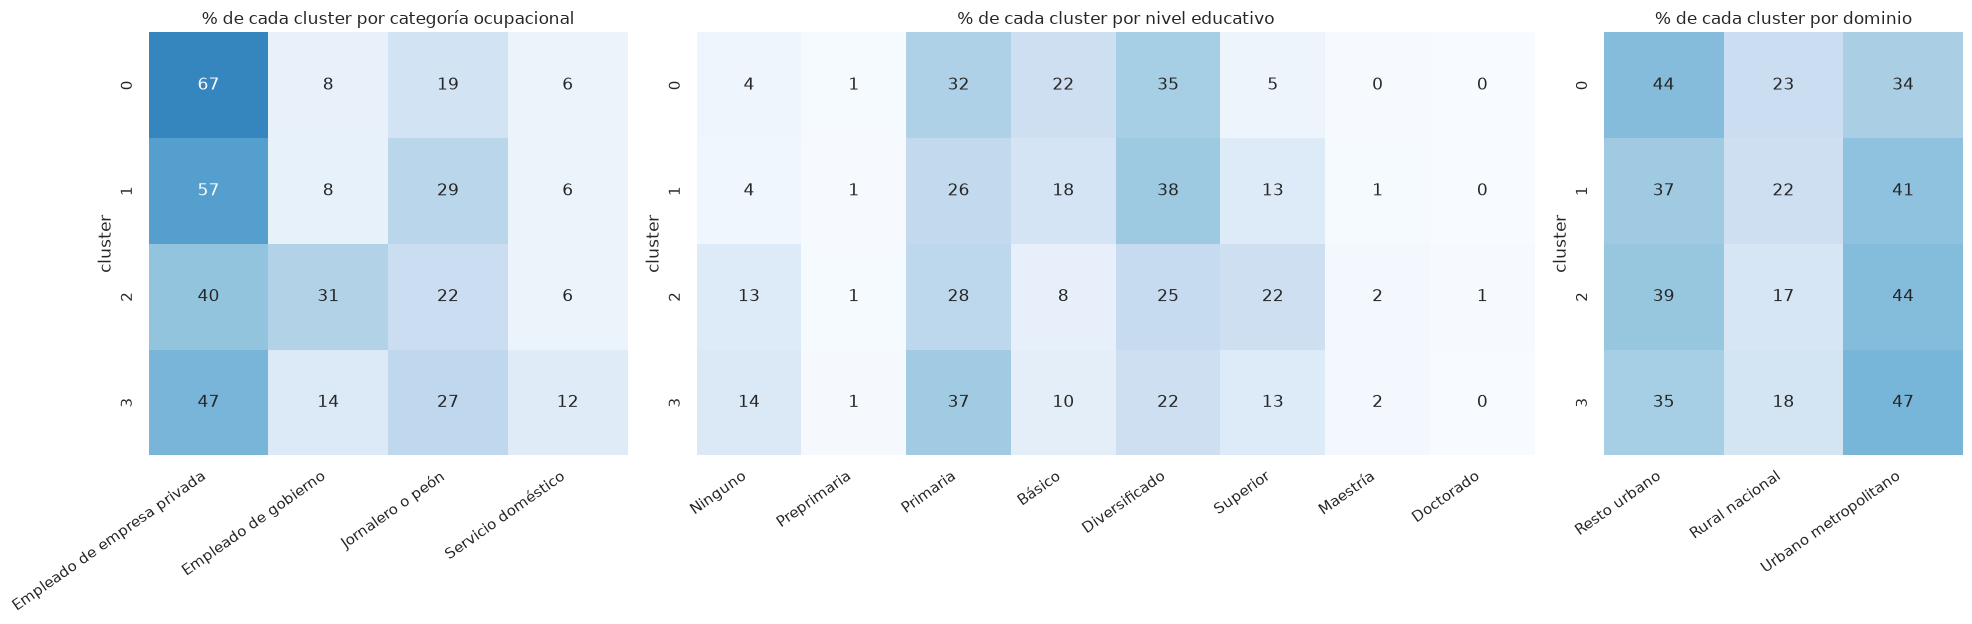

In [30]:
def composicion(col, orden=None):
    t = seg.groupBy("cluster", col).count().toPandas().pivot(index="cluster", columns=col, values="count").fillna(0)
    t = 100 * t.div(t.sum(axis=1), axis=0)
    if orden:
        t = t[[o for o in orden if o in t.columns]]
    return t


comp_cat = composicion("categoria_ocupacional")
comp_edu = composicion("nivel_educativo", ORDEN_EDU)
comp_dom = composicion("dominio")

fig, axes = plt.subplots(1, 3, figsize=(20, 1.2 + 0.8 * K_ELEGIDO + 2), gridspec_kw={"width_ratios": [4, 7, 3]})
for ax, t, titulo in [(axes[0], comp_cat, "Categoría ocupacional"), (axes[1], comp_edu, "Nivel educativo"), (axes[2], comp_dom, "Dominio")]:
    sns.heatmap(t, annot=True, fmt=".0f", cmap="Blues", vmin=0, vmax=100, cbar=False, ax=ax)
    ax.set_title(f"% de cada cluster por {titulo.lower()}"); ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=35)
    plt.setp(ax.get_xticklabels(), ha="right")
plt.tight_layout(); plt.show()

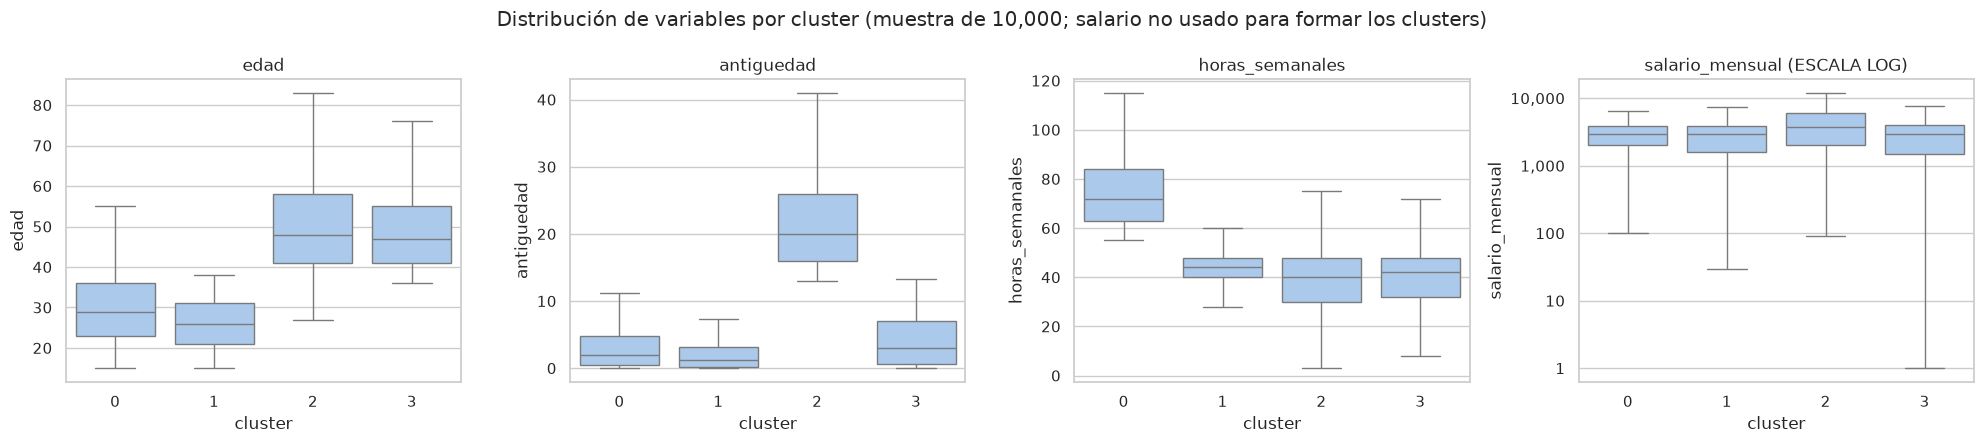

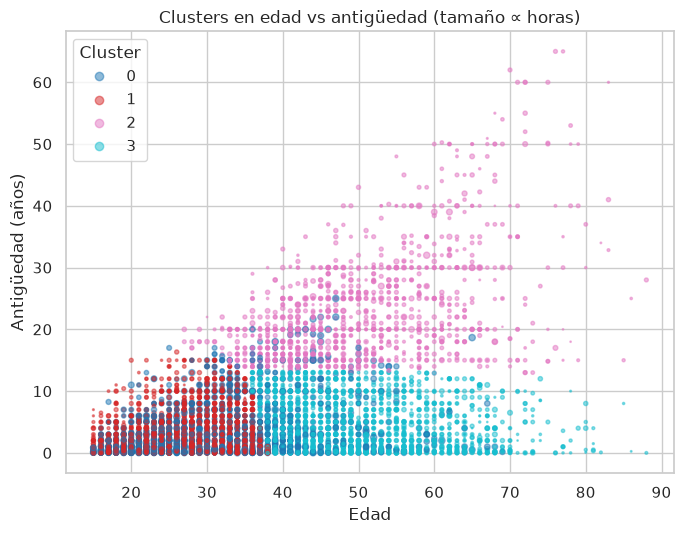

In [31]:
muestra_seg = (seg.sample(fraction=min(1.0, N_MUESTRA_GRAF / n25), seed=SEED).limit(N_MUESTRA_GRAF)
               .select(VARS_A + ["salario_mensual", "cluster"]).toPandas())
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, v in zip(axes, VARS_A + ["salario_mensual"]):
    sns.boxplot(data=muestra_seg, x="cluster", y=v, ax=ax, showfliers=False, color="#A1C9F4")
    ax.set_title(v + (" (ESCALA LOG)" if v == "salario_mensual" else ""))
    if v == "salario_mensual":
        ax.set_yscale("log"); ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.suptitle(f"Distribución de variables por cluster (muestra de {len(muestra_seg):,}; salario no usado para formar los clusters)")
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(muestra_seg["edad"], muestra_seg["antiguedad"], c=muestra_seg["cluster"], s=np.clip(muestra_seg["horas_semanales"] / 6, 1, 30),
                cmap="tab10", alpha=0.5)
ax.legend(*sc.legend_elements(), title="Cluster")
ax.set_xlabel("Edad"); ax.set_ylabel("Antigüedad (años)"); ax.set_title("Clusters en edad vs antigüedad (tamaño ∝ horas)")
plt.tight_layout(); plt.show()

### 4.4 Descripción de los clusters

Para que la etiqueta de cada grupo se base en los resultados, el centroide de cada cluster (en unidades originales) se clasifica con umbrales fijos y fáciles de interpretar:
- **Edad:** < 35 jóvenes; 35–54 adultos; ≥ 55 adultos mayores.
- **Antigüedad:** < 5 años baja; 5–10 media; > 10 alta.
- **Jornada:** < 35 h parcial; 35–48 h estándar (la jornada legal diurna es de 44–48 h); > 48 h extendida.

A esto se añaden la categoría ocupacional y el nivel educativo predominantes.

In [32]:
def describir(c):
    e, a, h = centros.loc[c, "edad"], centros.loc[c, "antiguedad"], centros.loc[c, "horas_semanales"]
    e = "jóvenes" if e < 35 else ("adultos" if e < 55 else "adultos mayores")
    a = "baja antigüedad" if a < 5 else ("antigüedad media" if a <= 10 else "alta antigüedad")
    j = "jornada parcial" if h < 35 else ("jornada estándar" if h <= 48 else "jornada extendida")
    cat = comp_cat.loc[c].idxmax(); edu = comp_edu.loc[c].idxmax()
    return f"{e.capitalize()}, {a}, {j}; predomina {cat.lower()} ({comp_cat.loc[c].max():.0f}%) y nivel {edu.lower()}"


perfil["descripcion"] = [describir(c) for c in perfil.index]
pd.set_option("display.max_colwidth", 200)
perfil[["n", "pct", "edad_mediana", "antig_mediana", "horas_mediana", "salario_mediano", "descripcion"]]

,n,pct,edad_mediana,antig_mediana,horas_mediana,salario_mediano,descripcion
cluster,,,,,,,
0,9255,17.45,29.00,2.00,72.00,"3,000.00","Jóvenes, baja antigüedad, jornada extendida; predomina empleado de empresa privada (67%) y nivel diversificado"
1,24400,46.02,26.00,1.25,44.00,"3,000.00","Jóvenes, baja antigüedad, jornada estándar; predomina empleado de empresa privada (57%) y nivel diversificado"
2,6846,12.91,48.00,20.00,40.00,"3,800.00","Adultos, alta antigüedad, jornada estándar; predomina empleado de empresa privada (40%) y nivel primaria"
3,12524,23.62,47.00,3.00,42.00,"3,000.00","Adultos, baja antigüedad, jornada estándar; predomina empleado de empresa privada (47%) y nivel primaria"


**Interpretación de la segmentación (K = 4).** Los números de cluster que asigna KMeans son arbitrarios; los perfiles se identifican por sus centroides:

| Perfil | Peso | Edad / antigüedad / horas (medianas) | Salario mediano | Rasgos |
|---|---|---|---|---|
| **1. Jóvenes que se inician** | ≈ 46 % | 26 años / 1.3 años / 44 h | Q3,000 | Jornada estándar y empleo reciente; mayoría en empresa privada (57 %) y 29 % jornaleros; nivel educativo intermedio. El grupo más numeroso. |
| **2. Jóvenes con jornada extendida** | ≈ 17 % | 29 años / 2 años / 72 h | Q3,000 | Jornadas muy largas (media 74 h); 67 % en empresa privada, pocos con educación superior (6 %). Trabajan mucho más por un salario similar, así que su **salario por hora es el más bajo** del grupo de tiempo completo. |
| **3. Adultos con empleo reciente** | ≈ 24 % | 47 años / 3 años / 42 h | Q3,000 | Edad madura pero poca antigüedad: rotación laboral o reinserción. Mayor peso del **servicio doméstico (12 %)** y de jornaleros (27 %); 52 % con primaria o menos. |
| **4. Trayectoria estable** | ≈ 13 % | 48 años / 20 años / 40 h | **Q3,800** | Alta antigüedad; concentra a los **empleados de gobierno (31 %)** y la mayor proporción con educación superior (25 %). Es el único perfil con salario mediano claramente mayor. |

- Los perfiles se definen por la **etapa de la vida laboral** (edad y antigüedad) y por la **intensidad de la jornada**. Que la jornada aparezca como un eje propio (perfil 2) es justamente lo que K = 2 no captaba.
- Aunque el salario no se usó para formar los grupos, solo el perfil de **trayectoria estable** se separa en salario (+27 % sobre la mediana general de Q3,000). Los otros tres tienen la misma mediana, y la dispersión salarial dentro de cada cluster es amplia. Esto confirma lo visto en la sección 3: edad, antigüedad y horas explican poco del salario por sí solas. La educación y la categoría ocupacional, que se agregan en los modelos supervisados, son las que marcan las mayores diferencias.
- Los resultados describen los **registros analizados sin ponderar**; con `FACTOR` se podría estimar cuántos asalariados del país pertenecen a cada perfil.

In [33]:
seg.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "cluster").write.mode("overwrite") \
   .parquet(str(DATA_PROC / "clusters_2025.parquet"))
print("Etiquetas de cluster guardadas (solo para análisis descriptivo; no se usan como predictor).")

Etiquetas de cluster guardadas (solo para análisis descriptivo; no se usan como predictor).


---
# 5. Pipeline de regresión lineal

**Tarea:** estimar `salario_mensual` a partir de exactamente seis predictores: `edad`, `antiguedad`, `horas_semanales` (numéricos) y `nivel_educativo`, `categoria_ocupacional`, `dominio` (categóricos). Es una predicción del salario del período observado, no un pronóstico futuro.

### 5.1 Entrenamiento, validación y prueba

Siguiendo la tabla de la guía (I–III de 2025 para desarrollo, IV‑2025 también para validación y luego para el entrenamiento final, I‑2026 reservado para la prueba):

- **Entrenamiento (selección de hiperparámetros):** 2025 T1–T3.
- **Validación:** 2025 T4.
- **Entrenamiento final** (una vez elegida la configuración): los cuatro trimestres de 2025 (`df25`) — incluye a T4.
- **Prueba final (actividad 7):** 2026 T1 (`df26`); no se toca hasta la sección 7.

Todos los componentes del pipeline (índices, codificación, escalamiento interno y el modelo) se ajustan **solo** con los datos de entrenamiento correspondientes a cada etapa.

In [34]:
CAT_COLS = ["nivel_educativo", "categoria_ocupacional", "dominio"]
NUM_COLS = ["edad", "antiguedad", "horas_semanales"]
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

TRAIN_PERIODOS_SUP = ["2025T1", "2025T2", "2025T3"]
VALID_PERIODO_SUP = "2025T4"

train_sup = df25.filter(F.col("periodo_archivo").isin(TRAIN_PERIODOS_SUP)).cache()
valid_sup = df25.filter(F.col("periodo_archivo") == VALID_PERIODO_SUP).cache()

print(f"Entrenamiento (T1–T3 2025): {train_sup.count():,} registros")
print(f"Validación (T4 2025): {valid_sup.count():,} registros")
print(f"Entrenamiento final (2025 completo): {df25.count():,} registros")
print(f"Prueba final (2026T1, reservada): {df26.count():,} registros")

Entrenamiento (T1–T3 2025): 40,361 registros
Validación (T4 2025): 12,664 registros
Entrenamiento final (2025 completo): 53,025 registros


Prueba final (2026T1, reservada): 13,258 registros


### 5.2 Modelo de referencia

Antes de ajustar cualquier modelo, se define un **modelo de referencia** (*baseline*) que predice, para todos los registros, la **media del salario en el conjunto de entrenamiento**. Es el modelo más simple que no usa ningún predictor; cualquier modelo con información real debe superarlo. Se recalcula la media sobre el conjunto de entrenamiento que corresponda en cada etapa (T1–T3 al validar, 2025 completo al evaluar en 2026).

In [35]:
def evaluar(pred, etiqueta):
    metricas = {}
    for m in ["mae", "rmse", "r2"]:
        ev = RegressionEvaluator(labelCol="salario_mensual", predictionCol="salario_predicho", metricName=m)
        metricas[m] = ev.evaluate(pred)
    return {"config": etiqueta, "MAE": metricas["mae"], "RMSE": metricas["rmse"], "R2": metricas["r2"]}


media_train_sup = train_sup.agg(F.mean("salario_mensual")).first()[0]
base_valid = valid_sup.withColumn("salario_predicho", F.lit(media_train_sup))
res_base_valid = evaluar(base_valid, "referencia (media)")
print(f"Media de referencia (T1–T3): Q{media_train_sup:,.2f}")
pd.DataFrame([res_base_valid]).set_index("config")

Media de referencia (T1–T3): Q3,383.12


,MAE,RMSE,R2
config,,,
referencia (media),"1,672.50","2,889.57",-0.00


### 5.3 Construcción del pipeline

a. `StringIndexer` (una instancia con las tres columnas) convierte cada categoría a un índice numérico; `handleInvalid="keep"` asigna un índice adicional a cualquier categoría no vista (por diseño no debería ocurrir, ya que `DESCONOCIDO` es una categoría más del diccionario).

b. `OneHotEncoder` transforma esos índices en vectores dispersos (uno por variable categórica).

c. `VectorAssembler` combina `edad`, `antiguedad`, `horas_semanales` con los tres vectores *one‑hot* en un solo vector `features`.

d. La estandarización se aplica mediante la opción interna de `LinearRegression` (`standardization=True`, su valor por defecto): estandariza los predictores para optimizar y devuelve los coeficientes ya en la escala original. No se usa además un `StandardScaler` externo, como pide la guía.

In [36]:
def pipeline_lr(regParam, elasticNetParam):
    idx = StringIndexer(inputCols=CAT_COLS, outputCols=[f"{c}_idx" for c in CAT_COLS], handleInvalid="keep")
    ohe = OneHotEncoder(inputCols=[f"{c}_idx" for c in CAT_COLS], outputCols=[f"{c}_ohe" for c in CAT_COLS])
    ensamblador = VectorAssembler(inputCols=NUM_COLS + [f"{c}_ohe" for c in CAT_COLS], outputCol="features")
    lr = LinearRegression(featuresCol="features", labelCol="salario_mensual", predictionCol="salario_predicho",
                           regParam=regParam, elasticNetParam=elasticNetParam, standardization=True)
    return Pipeline(stages=[idx, ohe, ensamblador, lr])


# Configuraciones de regularización probadas (regParam, elasticNetParam):
CONFIGS_LR = [
    ("sin_reg", 0.0, 0.0),        # sin penalización (referencia interna)
    ("ridge_leve", 0.3, 0.0),     # L2 leve
    ("ridge_fuerte", 50.0, 0.0),  # L2 fuerte
    ("lasso_fuerte", 50.0, 1.0),  # L1 fuerte
]

resultados_lr, modelos_lr = [], {}
for nombre, regParam, elastic in CONFIGS_LR:
    modelo = pipeline_lr(regParam, elastic).fit(train_sup)
    pred_valid = modelo.transform(valid_sup)
    r = evaluar(pred_valid, nombre)
    r["regParam"], r["elasticNetParam"] = regParam, elastic
    resultados_lr.append(r)
    modelos_lr[nombre] = modelo

res_lr = pd.DataFrame(resultados_lr).set_index("config")
res_lr

,MAE,RMSE,R2,regParam,elasticNetParam
config,,,,,
sin_reg,"1,210.14","2,186.42",0.43,0.00,0.00
ridge_leve,"1,210.12","2,186.42",0.43,0.30,0.00
ridge_fuerte,"1,207.91","2,187.15",0.43,50.00,0.00
lasso_fuerte,"1,196.66","2,194.96",0.42,50.00,1.00


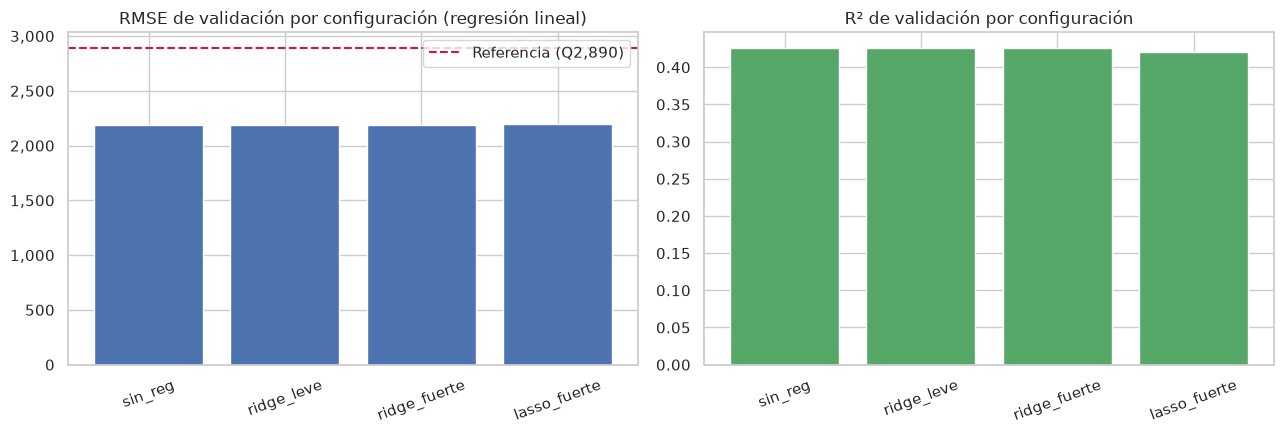

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].bar(res_lr.index, res_lr["RMSE"], color="#4C72B0")
axes[0].axhline(res_base_valid["RMSE"], color="crimson", ls="--", label=f"Referencia (Q{res_base_valid['RMSE']:,.0f})")
axes[0].set_title("RMSE de validación por configuración (regresión lineal)"); axes[0].legend()
axes[1].bar(res_lr.index, res_lr["R2"], color="#55A868")
axes[1].set_title("R² de validación por configuración")
for ax in axes:
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.2f}" if ax is axes[1] else "{x:,.0f}"))
plt.tight_layout(); plt.show()

**Selección de configuración.** Las cuatro configuraciones obtienen un desempeño casi idéntico (RMSE entre Q2,186 y Q2,195; R² entre 0.421 y 0.426): con **40,361** registros de entrenamiento y solo **21** columnas en el vector de predictores, el modelo no está sobreajustado, así que penalizar los coeficientes apenas cambia el ajuste. La configuración **sin regularización (`regParam = 0`)** obtiene el **menor RMSE de validación (Q2,186.42**, MAE Q1,210.14, R² 0.4257) y es la que se usa en adelante. `lasso_fuerte` logra el mejor MAE (Q1,196.66) porque el `solver` de mínimos cuadrados detectó inestabilidad numérica (advertencia *"Cholesky solver failed due to singular covariance matrix"*, por categorías con muy pocos registros como doctorado) y una penalización L1 fuerte encoge esos coeficientes inestables; a cambio, empeora ligeramente el RMSE porque reduce la precisión en esos mismos grupos pequeños, que pesan más en una métrica cuadrática. Frente al **modelo de referencia** (predecir la media: RMSE Q2,889.57, R² ≈ 0), la regresión lineal reduce el RMSE en **24.3 %** y el MAE en **27.6 %**, y explica cerca del **43 %** de la varianza del salario en el conjunto de validación.

In [38]:
MODELOS_DIR = DATA_PROC / "modelos"
MODELOS_DIR.mkdir(parents=True, exist_ok=True)

mejor_lr_nombre = res_lr["RMSE"].idxmin()
mejor_lr_cfg = [c for c in CONFIGS_LR if c[0] == mejor_lr_nombre][0]
print(f"Configuración elegida (menor RMSE de validación): {mejor_lr_nombre} "
      f"(regParam={mejor_lr_cfg[1]}, elasticNetParam={mejor_lr_cfg[2]})")

# Entrenamiento final: se reajustan TODOS los componentes con 2025 completo (T1–T4)
pipe_lr_final = pipeline_lr(mejor_lr_cfg[1], mejor_lr_cfg[2]).fit(df25)
pipe_lr_final.write().overwrite().save(str(MODELOS_DIR / "regresion_lineal"))

media_full = df25.agg(F.mean("salario_mensual")).first()[0]
print(f"Media de referencia (2025 completo): Q{media_full:,.2f}")
print("Modelo de regresión lineal final guardado en", MODELOS_DIR / "regresion_lineal")

Configuración elegida (menor RMSE de validación): sin_reg (regParam=0.0, elasticNetParam=0.0)


Media de referencia (2025 completo): Q3,421.68
Modelo de regresión lineal final guardado en ../data/processed/modelos/regresion_lineal


**Coeficientes del modelo final** (efecto sobre el salario respecto al intercepto, en quetzales; predictores numéricos ya en su escala original porque `standardization` solo afecta la optimización):

In [39]:
def nombres_de_vector(pipeline_ajustado, df_base):
    meta = pipeline_ajustado.transform(df_base.limit(1)).schema["features"].metadata["ml_attr"]["attrs"]
    nombres = [None] * sum(len(v) for v in meta.values())
    for grupo in meta.values():
        for a in grupo:
            nombres[a["idx"]] = a["name"]
    return nombres


lr_model_final = pipe_lr_final.stages[-1]
nombres_lr = nombres_de_vector(pipe_lr_final, df25)
coef_lr = (pd.DataFrame({"variable": nombres_lr, "coeficiente": lr_model_final.coefficients.toArray()})
           .sort_values("coeficiente", key=np.abs, ascending=False))
print(f"Intercepto: Q{lr_model_final.intercept:,.2f}")
coef_lr.head(12).set_index("variable")

Intercepto: Q1,848.43


,coeficiente
variable,
nivel_educativo_ohe_Doctorado,"9,279.79"
nivel_educativo_ohe_Maestría,"6,964.39"
nivel_educativo_ohe_Superior,"1,802.53"
categoria_ocupacional_ohe_Servicio doméstico,"-1,428.91"
categoria_ocupacional_ohe_Empleado de gobierno,"1,414.03"
nivel_educativo_ohe_Ninguno,"-1,249.30"
nivel_educativo_ohe_Preprimaria,-970.70
nivel_educativo_ohe_Primaria,-763.01
categoria_ocupacional_ohe_Jornalero o peón,-611.30


---
# 6. Pipeline de Random Forest

### 6.1 Construcción del pipeline

Se reutilizan los mismos pasos (a) y (b) de indexación y codificación *one‑hot* de las variables categóricas, y (c) el mismo `VectorAssembler`. `RandomForestRegressor` no requiere estandarizar los predictores porque cada árbol decide umbrales sobre cada variable de forma independiente; la escala de una variable no afecta en qué valor se corta.

In [40]:
def pipeline_rf(numTrees, maxDepth):
    idx = StringIndexer(inputCols=CAT_COLS, outputCols=[f"{c}_idx" for c in CAT_COLS], handleInvalid="keep")
    ohe = OneHotEncoder(inputCols=[f"{c}_idx" for c in CAT_COLS], outputCols=[f"{c}_ohe" for c in CAT_COLS])
    ensamblador = VectorAssembler(inputCols=NUM_COLS + [f"{c}_ohe" for c in CAT_COLS], outputCol="features")
    rf = RandomForestRegressor(featuresCol="features", labelCol="salario_mensual", predictionCol="salario_predicho",
                                numTrees=numTrees, maxDepth=maxDepth, seed=SEED)
    return Pipeline(stages=[idx, ohe, ensamblador, rf])


# Configuraciones probadas (numTrees, maxDepth), semilla fija:
CONFIGS_RF = [
    ("rf_pequeno", 40, 5),
    ("rf_medio", 80, 8),
    ("rf_grande", 120, 10),
]

resultados_rf, modelos_rf = [], {}
for nombre, numTrees, maxDepth in CONFIGS_RF:
    modelo = pipeline_rf(numTrees, maxDepth).fit(train_sup)
    pred_valid = modelo.transform(valid_sup)
    r = evaluar(pred_valid, nombre)
    r["numTrees"], r["maxDepth"] = numTrees, maxDepth
    resultados_rf.append(r)
    modelos_rf[nombre] = modelo

res_rf = pd.DataFrame(resultados_rf).set_index("config")
res_rf

,MAE,RMSE,R2,numTrees,maxDepth
config,,,,,
rf_pequeno,"1,161.54","2,161.02",0.44,40,5
rf_medio,"1,095.44","2,033.37",0.50,80,8
rf_grande,"1,075.20","1,983.88",0.53,120,10


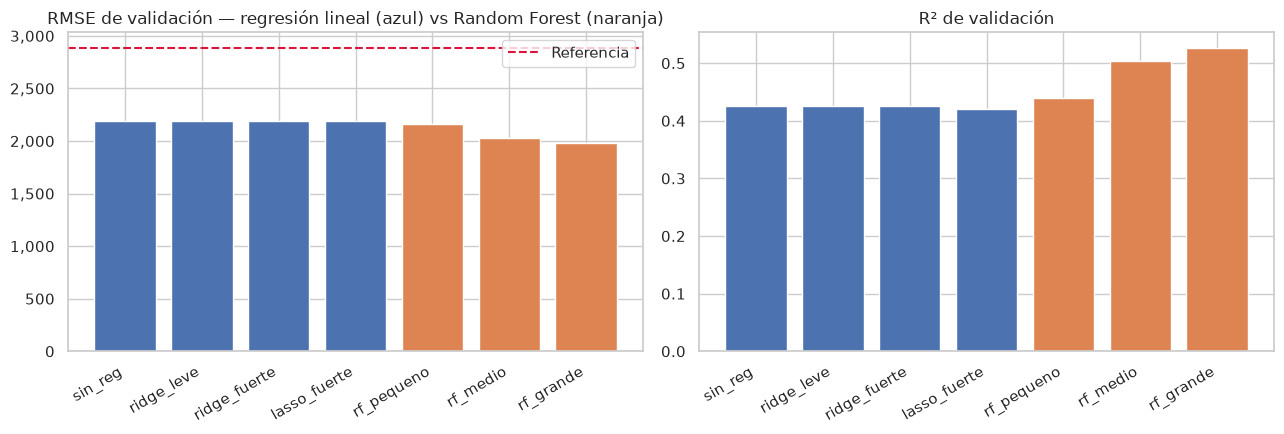

In [41]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
todas = pd.concat([res_lr[["RMSE", "R2"]], res_rf[["RMSE", "R2"]]])
colores = ["#4C72B0"] * len(res_lr) + ["#DD8452"] * len(res_rf)
axes[0].bar(todas.index, todas["RMSE"], color=colores)
axes[0].axhline(res_base_valid["RMSE"], color="crimson", ls="--", label="Referencia")
axes[0].set_title("RMSE de validación — regresión lineal (azul) vs Random Forest (naranja)"); axes[0].legend()
axes[1].bar(todas.index, todas["R2"], color=colores)
axes[1].set_title("R² de validación")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
    plt.setp(ax.get_xticklabels(), ha="right")
axes[0].yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

**Selección de configuración.** El desempeño mejora de forma consistente con más árboles y mayor profundidad: `rf_pequeno` (40 árboles, profundidad 5) obtiene RMSE Q2,161.02; `rf_medio` (80, 8) baja a Q2,033.37; `rf_grande` (120, 10) logra el **menor RMSE de validación (Q1,983.88**, MAE Q1,075.20, R² 0.53) y es la configuración elegida. La mejora entre configuraciones es decreciente (de pequeño a medio el RMSE baja 5.9 %; de medio a grande, 2.4 %), señal de que profundidades mayores aportarían cada vez menos y aumentarían el riesgo de sobreajuste, por lo que no se probaron árboles más profundos.

**Random Forest frente a la regresión lineal (validación).** Con la misma partición, Random Forest **supera a la regresión lineal en las tres métricas**: RMSE Q1,983.88 frente a Q2,186.42 (**‑9.3 %**), MAE Q1,075.20 frente a Q1,210.14 (**‑11.1 %**) y R² 0.53 frente a 0.43. La ventaja es coherente con la naturaleza de los datos: la regresión lineal fuerza que cada categoría (por ejemplo, cada nivel educativo) sume un efecto **constante** al salario, mientras que Random Forest puede aprender **interacciones y umbrales** (p. ej., que la combinación de educación superior *y* categoría de gobierno se asocie a salarios mucho mayores que la suma de sus efectos por separado, o que el efecto de las horas trabajadas cambie según la categoría ocupacional) sin que el equipo tenga que especificarlas a mano.

In [42]:
mejor_rf_nombre = res_rf["RMSE"].idxmin()
mejor_rf_cfg = [c for c in CONFIGS_RF if c[0] == mejor_rf_nombre][0]
print(f"Configuración elegida (menor RMSE de validación): {mejor_rf_nombre} "
      f"(numTrees={mejor_rf_cfg[1]}, maxDepth={mejor_rf_cfg[2]})")

pipe_rf_final = pipeline_rf(mejor_rf_cfg[1], mejor_rf_cfg[2]).fit(df25)
pipe_rf_final.write().overwrite().save(str(MODELOS_DIR / "random_forest"))
print("Modelo de Random Forest final guardado en", MODELOS_DIR / "random_forest")

Configuración elegida (menor RMSE de validación): rf_grande (numTrees=120, maxDepth=10)


Modelo de Random Forest final guardado en ../data/processed/modelos/random_forest


### 6.2 Importancia de variables (modelo final)

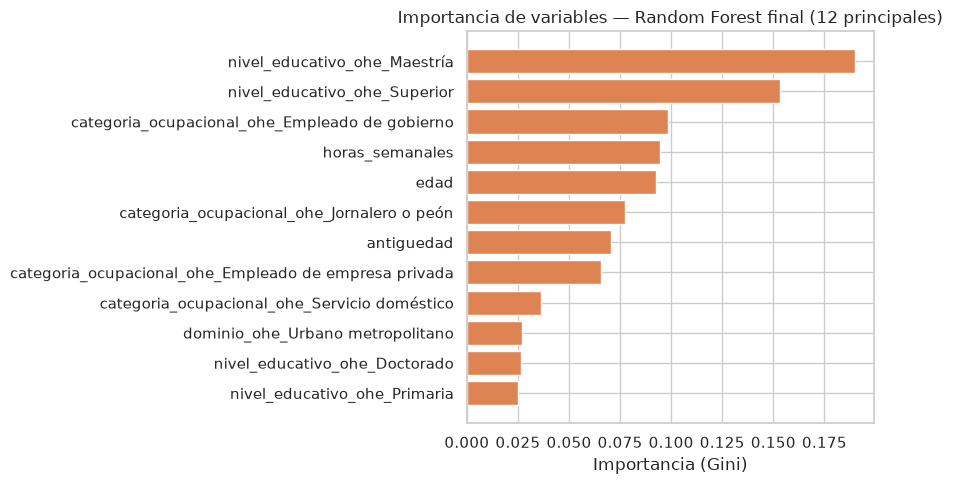

,importancia
variable,
nivel_educativo_ohe_Maestría,0.19
nivel_educativo_ohe_Superior,0.15
categoria_ocupacional_ohe_Empleado de gobierno,0.10
horas_semanales,0.09
edad,0.09
categoria_ocupacional_ohe_Jornalero o peón,0.08
antiguedad,0.07
categoria_ocupacional_ohe_Empleado de empresa privada,0.07
categoria_ocupacional_ohe_Servicio doméstico,0.04


In [43]:
pred_ejemplo = pipe_rf_final.transform(df25.limit(1))
meta_attrs = pred_ejemplo.schema["features"].metadata["ml_attr"]["attrs"]
nombres_features = [None] * sum(len(v) for v in meta_attrs.values())
for grupo in meta_attrs.values():
    for a in grupo:
        nombres_features[a["idx"]] = a["name"]

rf_model_final = pipe_rf_final.stages[-1]
importancias = (pd.DataFrame({"variable": nombres_features, "importancia": rf_model_final.featureImportances.toArray()})
                 .sort_values("importancia", ascending=False).head(12))

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(importancias["variable"][::-1], importancias["importancia"][::-1], color="#DD8452")
ax.set_title("Importancia de variables — Random Forest final (12 principales)")
ax.set_xlabel("Importancia (Gini)")
plt.tight_layout(); plt.show()
importancias.set_index("variable")

**Interpretación.** Las variables con mayor importancia son las categorías de **educación alta** (Maestría 0.19, Superior 0.15) y de **categoría ocupacional** (empleado de gobierno 0.10, jornalero 0.08, empresa privada 0.07), seguidas de las tres numéricas (horas semanales 0.09, edad 0.09, antigüedad 0.07); el dominio aporta poco (Urbano metropolitano 0.03 y menos). Coincide con los coeficientes de la regresión lineal (tabla anterior): Doctorado, Maestría y Superior son los efectos de mayor magnitud sobre el intercepto, y servicio doméstico el más negativo. Ambos modelos coinciden en que **la educación y la categoría ocupacional explican más que las variables numéricas**, en línea con lo observado en las secciones 2 y 3: la correlación de edad, antigüedad y horas con el salario es débil (r ≤ 0.18) y las diferencias grandes de salario aparecen entre grupos categóricos.

---
# 7. Entrenamiento final y evaluación en 2026

Con la configuración ya seleccionada por algoritmo (sección 5 y 6) y **reentrenada con los cuatro trimestres de 2025** (`pipe_lr_final`, `pipe_rf_final`), se generan predicciones sobre el primer trimestre de 2026 (`df26`), preparado con exactamente las mismas reglas de la sección 1. Los dos modelos y el modelo de referencia se evalúan sobre **los mismos registros** de prueba.

In [44]:
pred_test_base = df26.withColumn("salario_predicho", F.lit(media_full))
pred_test_lr = pipe_lr_final.transform(df26)
pred_test_rf = pipe_rf_final.transform(df26)

comparacion = pd.DataFrame([
    evaluar(pred_test_base, "Referencia (media 2025)"),
    evaluar(pred_test_lr, "Regresión lineal"),
    evaluar(pred_test_rf, "Random Forest"),
]).set_index("config")
comparacion.insert(0, "n_prueba", df26.count())
comparacion

,n_prueba,MAE,RMSE,R2
config,,,,
Referencia (media 2025),13258,"1,718.09","2,871.42",-0.00
Regresión lineal,13258,"1,240.71","2,163.75",0.43
Random Forest,13258,"1,101.25","1,957.90",0.53


In [45]:
comparacion_valid_test = pd.DataFrame({
    "RMSE_validacion_2025T4": [res_base_valid["RMSE"], res_lr.loc[mejor_lr_nombre, "RMSE"], res_rf.loc[mejor_rf_nombre, "RMSE"]],
    "RMSE_prueba_2026T1": comparacion["RMSE"].values,
    "R2_validacion_2025T4": [res_base_valid["R2"], res_lr.loc[mejor_lr_nombre, "R2"], res_rf.loc[mejor_rf_nombre, "R2"]],
    "R2_prueba_2026T1": comparacion["R2"].values,
}, index=["Referencia", "Regresión lineal", "Random Forest"])
comparacion_valid_test

,RMSE_validacion_2025T4,RMSE_prueba_2026T1,R2_validacion_2025T4,R2_prueba_2026T1
Referencia,"2,889.57","2,871.42",-0.00,-0.00
Regresión lineal,"2,186.42","2,163.75",0.43,0.43
Random Forest,"1,983.88","1,957.90",0.53,0.53


**Interpretación.** En la prueba de 2026T1 (13,258 registros, no usados en ninguna etapa anterior):

- El **modelo de referencia** vuelve a tener R² prácticamente nulo (‑0.003): confirma que predecir la media no captura ninguna variación del salario, ni siquiera de un trimestre a otro.
- La **regresión lineal** obtiene RMSE Q2,163.75, MAE Q1,240.71 y R² 0.43 (redujo el RMSE de la referencia en 24.6 %).
- **Random Forest** vuelve a ser el mejor modelo: RMSE Q1,957.90, MAE Q1,101.25 y **R² 0.53** (redujo el RMSE de la referencia en 31.8 % y el de la regresión lineal en 9.5 %).
- Ambos modelos generalizan bien: sus métricas en 2026T1 son muy cercanas a las de validación (2025T4) — de hecho, el RMSE de los dos es **ligeramente menor** en 2026T1 que en validación (regresión lineal: Q2,186.42 → Q2,163.75; Random Forest: Q1,983.88 → Q1,957.90). No hay señal de sobreajuste al conjunto de desarrollo; la relación entre los seis predictores y el salario parece estable entre 2025 y el primer trimestre de 2026.
- **Random Forest obtiene mejores resultados que la regresión lineal en los tres conjuntos** (entrenamiento/validación y prueba), de forma consistente y con un margen similar (8–10 % de RMSE). La diferencia se explica, como en la sección 6.2, por su capacidad de capturar interacciones y umbrales entre educación, categoría ocupacional y las variables numéricas que un modelo lineal aditivo no puede representar sin que se construyan esas interacciones a mano.

---
# 8. Visualización y análisis de errores

Se define el residuo como `residuo = salario_mensual − salario_predicho`: un **residuo positivo indica subestimación** (el modelo predijo menos de lo real) y uno **negativo, sobreestimación**. Los gráficos de dispersión usan la **misma muestra** de hasta 5,000 registros de 2026T1 para los dos modelos, de modo que sean directamente comparables; las tablas por grupo se calculan sobre **todos** los registros de prueba (13,258).

In [46]:
comp_test = (
    pred_test_lr.select(*CLAVE, "salario_mensual", "nivel_educativo", "dominio",
                         F.col("salario_predicho").alias("pred_lr"))
    .join(pred_test_rf.select(*CLAVE, F.col("salario_predicho").alias("pred_rf")), CLAVE)
    .withColumn("residuo_lr", F.col("salario_mensual") - F.col("pred_lr"))
    .withColumn("residuo_rf", F.col("salario_mensual") - F.col("pred_rf"))
).cache()

N_MUESTRA_ERROR = 5_000
n_test = comp_test.count()
muestra_pred = (comp_test.sample(fraction=min(1.0, N_MUESTRA_ERROR / n_test), seed=SEED)
                 .limit(N_MUESTRA_ERROR).toPandas())
print(f"Muestra para gráficos de error: {len(muestra_pred):,} de {n_test:,} registros de 2026T1")

Muestra para gráficos de error: 5,000 de 13,258 registros de 2026T1


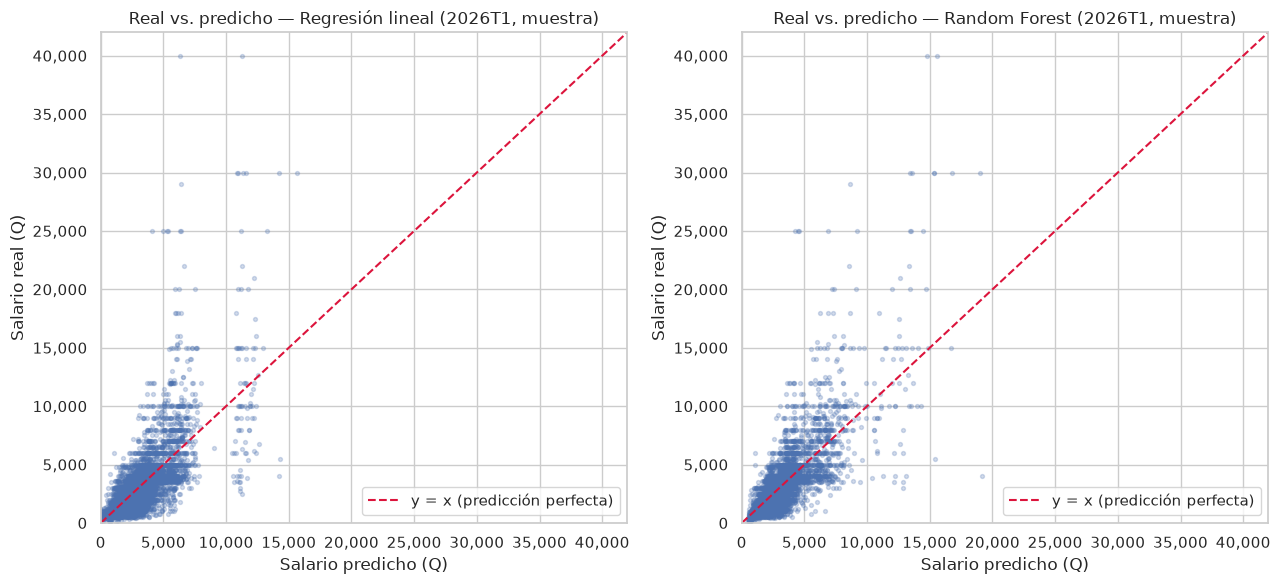

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
lims = (0, max(muestra_pred["salario_mensual"].max(), muestra_pred["pred_lr"].max(), muestra_pred["pred_rf"].max()) * 1.05)
for ax, col, titulo in [(axes[0], "pred_lr", "Regresión lineal"), (axes[1], "pred_rf", "Random Forest")]:
    ax.scatter(muestra_pred[col], muestra_pred["salario_mensual"], s=8, alpha=0.25, color="#4C72B0")
    ax.plot(lims, lims, color="crimson", ls="--", label="y = x (predicción perfecta)")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Salario predicho (Q)"); ax.set_ylabel("Salario real (Q)")
    ax.set_title(f"Real vs. predicho — {titulo} (2026T1, muestra)")
    ax.legend()
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
    ax.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

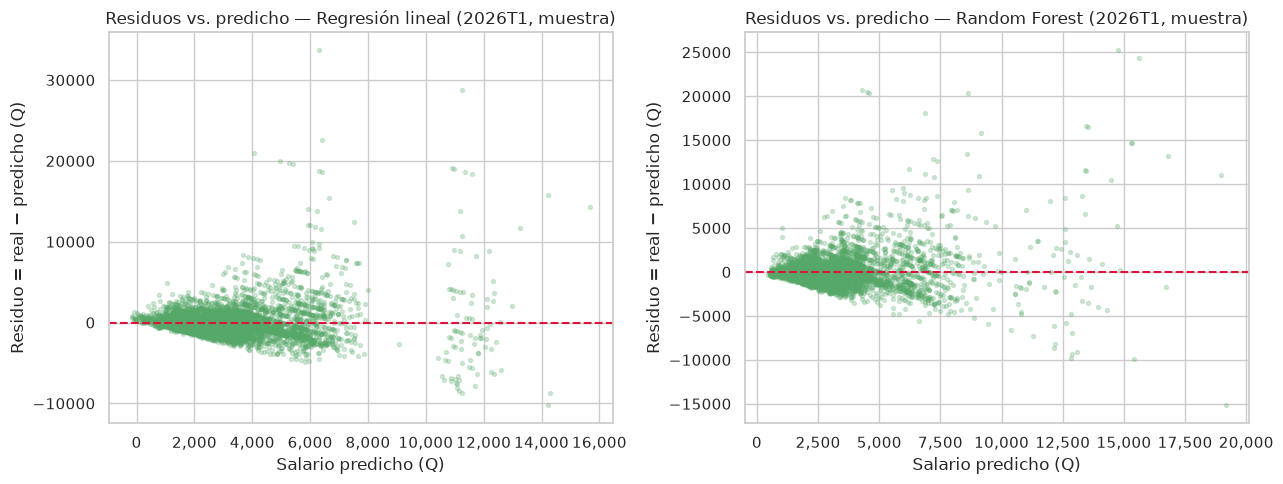

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, pred_col, res_col, titulo in [(axes[0], "pred_lr", "residuo_lr", "Regresión lineal"),
                                       (axes[1], "pred_rf", "residuo_rf", "Random Forest")]:
    ax.scatter(muestra_pred[pred_col], muestra_pred[res_col], s=8, alpha=0.25, color="#55A868")
    ax.axhline(0, color="crimson", ls="--")
    ax.set_xlabel("Salario predicho (Q)"); ax.set_ylabel("Residuo = real − predicho (Q)")
    ax.set_title(f"Residuos vs. predicho — {titulo} (2026T1, muestra)")
    ax.xaxis.set_major_formatter(mticker.StrMethodFormatter("{x:,.0f}"))
plt.tight_layout(); plt.show()

Ambos gráficos muestran el mismo patrón: por debajo de aproximadamente Q6,000 predichos los puntos se reparten alrededor de la línea *y = x* / la línea de cero, pero **por encima de ese valor casi todos los puntos quedan por arriba de la diagonal** (residuo positivo): el modelo predice salarios más bajos que los reales para los sueldos altos. El patrón es algo menos marcado en Random Forest, cuyos residuos están un poco menos dispersos.

In [49]:
def tabla_por_grupo(col):
    filas = []
    for nombre, res_col, pred_col in [("Regresión lineal", "residuo_lr", "pred_lr"), ("Random Forest", "residuo_rf", "pred_rf")]:
        t = (comp_test.groupBy(col).agg(
                F.count("*").alias("n"),
                F.mean(F.abs(res_col)).alias("MAE"),
                F.mean(res_col).alias("error_medio"))
             .toPandas().assign(modelo=nombre))
        filas.append(t)
    return pd.concat(filas).pivot(index=col, columns="modelo", values=["n", "MAE", "error_medio"])


print("--- Por nivel educativo ---")
display(tabla_por_grupo("nivel_educativo").reindex([o for o in ORDEN_EDU if o != "DESCONOCIDO"]).dropna(how="all").round(1))
print("--- Por dominio ---")
display(tabla_por_grupo("dominio").round(1))

--- Por nivel educativo ---


n                            MAE                    error_medio                 
modelo          Random Forest Regresión lineal Random Forest Regresión lineal Random Forest Regresión lineal
nivel_educativo                                                                                             
Ninguno              1,016.00         1,016.00        651.60           823.50        -49.40           109.30
Preprimaria             80.00            80.00        641.80           735.20       -148.40            88.80
Primaria             3,957.00         3,957.00        755.60           870.00         43.60            54.60
Básico               2,164.00         2,164.00        819.30           894.50        116.50           127.80
Diversificado        4,117.00         4,117.00      1,017.20         1,109.30        135.10           104.00
Superior             1,729.00         1,729.00      2,291.00         2,566.40        271.00           295.50
Maestría               183.00           183.00      4,632.40         5,552.90       -224.90          -131.50
Doctorado               12.00            12.00     10,610.30        12,919.30      5,771.00         6,062.70

--- Por dominio ---


n                            MAE                    error_medio                 
modelo               Random Forest Regresión lineal Random Forest Regresión lineal Random Forest Regresión lineal
dominio                                                                                                          
Resto urbano              4,846.00         4,846.00      1,042.60         1,189.60         86.00           134.30
Rural nacional            2,780.00         2,780.00        773.50           913.60          9.40            65.20
Urbano metropolitano      5,632.00         5,632.00      1,313.50         1,446.10        172.60           136.00

**Lectura de las tablas por grupo.** El **MAE crece con el nivel educativo** en los dos modelos: es menor en primaria/básico/preprimaria (Q640–Q900) y mucho mayor en superior, maestría y sobre todo doctorado (Q4,600–Q12,900, con solo 12 registros de prueba); el **error medio** (sesgo) también es positivo y creciente en ese tramo — superior se **subestima** de forma sistemática en ambos modelos (+Q271 en Random Forest, +Q296 en la lineal) y doctorado aún más (+Q5,771 y +Q6,063). Maestría, en cambio, muestra un sesgo **negativo** (sobreestimación leve, ‑Q225 y ‑Q132): es un grupo pequeño (183 registros) con salarios muy dispersos, no sistemáticamente subestimado. Por dominio, el MAE es mayor en **urbano metropolitano** (Q1,314–Q1,446) que en resto urbano y, sobre todo, rural nacional (Q774–Q914), reflejo de que el dominio con salarios más altos y dispersos es también el más difícil de predecir. Random Forest tiene **menor MAE que la regresión lineal en todos los grupos** (p. ej. superior: Q2,291 vs Q2,566; rural nacional: Q774 vs Q914), consistente con su mejor RMSE global, aunque no elimina el sesgo hacia arriba en los grupos de salario alto.

In [50]:
p90 = df26.agg(F.expr("percentile(salario_mensual, 0.9)")).first()[0]
alto = comp_test.filter(F.col("salario_mensual") >= p90)
bajo = comp_test.filter(F.col("salario_mensual") < p90)
n_alto, n_bajo = alto.count(), bajo.count()

filas_pct = []
for nombre, res_col in [("Regresión lineal", "residuo_lr"), ("Random Forest", "residuo_rf")]:
    filas_pct.append({
        "modelo": nombre,
        "error_medio_top10pct (>= P90)": alto.agg(F.mean(res_col)).first()[0],
        "error_medio_resto90pct (< P90)": bajo.agg(F.mean(res_col)).first()[0],
    })
print(f"P90 del salario en 2026T1: Q{p90:,.0f} | top 10%: {n_alto:,} registros | resto: {n_bajo:,} registros")
pd.DataFrame(filas_pct).set_index("modelo").round(1)

P90 del salario en 2026T1: Q6,000 | top 10%: 1,542 registros | resto: 11,716 registros


,error_medio_top10pct (>= P90),error_medio_resto90pct (< P90)
modelo,,
Regresión lineal,"3,191.80",-283.70
Random Forest,"2,843.20",-253.40


### Discusión final

**¿Hay tendencia a subestimar o sobreestimar según el nivel del salario?** Sí, y es sistemática: para el **10 % de salarios más altos** (≥ Q6,000, 1,542 registros de 2026T1) el error medio es **+Q3,192 en la regresión lineal y +Q2,843 en Random Forest**: ambos modelos **subestiman fuertemente** los salarios altos. Para el **90 % restante** (11,716 registros) el error medio es pequeño y **negativo** (‑Q284 en la lineal, ‑Q253 en Random Forest): una **ligera sobreestimación** de los salarios típicos. Es el patrón esperable dado lo visto en la sección 2: el salario tiene una asimetría muy fuerte a la derecha (coeficiente 6.0, máximo 33 veces la mediana) y los modelos, entrenados para minimizar el error promedio, aprenden a acertar bien en la mayoría de los casos (salarios entre Q1,800 y Q4,000) a costa de no alcanzar los valores extremos de la cola. Random Forest atenúa el sesgo en la cola alta (‑10.9 % frente a la lineal) porque puede aislar combinaciones de educación y categoría asociadas a sueldos altos en hojas específicas del árbol, pero no lo elimina: con solo seis predictores observados no hay información suficiente para distinguir, dentro de "educación superior y empleado de gobierno", a la persona que gana Q6,000 de la que gana Q20,000.

**Síntesis de todo el laboratorio.** El análisis exploratorio (secciones 1–4) ya anticipaba estos resultados: el salario es la variable con mayor dispersión y asimetría de la base; su correlación lineal con edad, antigüedad y horas es débil (r ≤ 0.18); y las diferencias grandes aparecen entre grupos (hasta 5× entre categorías ocupacionales y 8× entre niveles educativos). La segmentación por KMeans confirmó que edad, antigüedad y horas definen perfiles de vida laboral pero **no** separan bien el salario (la mediana es casi la misma en tres de los cuatro clusters). Los modelos supervisados de las secciones 5–7 confirman esa misma historia desde la predicción: con R² entre 0.43 y 0.53, **la mayor parte de la variación del salario no la explican estas seis variables**, y la fracción que sí explican proviene sobre todo de la **educación y la categoría ocupacional**, no de la edad, la antigüedad o las horas trabajadas. Random Forest es consistentemente el mejor de los dos algoritmos (mejor RMSE, MAE y R² en validación y en la prueba de 2026), porque modela interacciones y umbrales entre esas variables categóricas y numéricas sin necesidad de especificarlos, aunque comparte con la regresión lineal la misma limitación de fondo: ambos subestiman de forma importante a los salarios más altos. Estas conclusiones describen a los **asalariados de 15 años o más con salario positivo registrado en la ENEIC de 2025–2026**, sin ponderar por `FACTOR`; no son estimaciones oficiales de la población guatemalteca ni deben leerse como una recomendación normativa sobre cuánto debería ganar una persona.